<a href="https://colab.research.google.com/github/hojun-code/2026-BDA-team/blob/main/BDA_team.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 준비

In [2]:
!pip install koreanize-matplotlib
import koreanize_matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 57.8 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
# 데이터 출처: https://data.seoul.go.kr/dataList/OA-12252/S/1/datasetView.do
df = pd.read_csv('/content/gdrive/MyDrive/subway.csv', encoding='cp949')

df["사용월"] = pd.PeriodIndex(df["사용월"], freq="M")

# 나중에 자주 쓸 열 추가
df['총승차인원'] = df[[f'{i:02d}시-{i+1:02d}시 승차인원' for i in range(24)]].sum(axis=1)
df['총하차인원'] = df[[f'{i:02d}시-{i+1:02d}시 하차인원' for i in range(24)]].sum(axis=1)

df = df.drop(columns=['작업일자']) # 필요 없는 열 제거

## 분석

### 데이터 개요 확인

In [ ]:
df.head()

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,총승차인원,총하차인원
0,2026-04,1호선,동대문,699,14,10785,1967,9753,7375,17418,...,1041,3359,1,337,0,0,0,0,421093,408344
1,2026-04,1호선,동묘앞,203,10,3112,914,4394,6211,9605,...,156,2421,0,332,0,0,0,0,346632,361039
2,2026-04,1호선,서울역,714,53,11801,11865,39975,72460,124120,...,4653,8780,23,247,0,0,0,0,2468049,2402242
3,2026-04,1호선,시청,175,0,1917,6324,4110,33548,8007,...,688,942,3,18,0,0,0,0,823504,832287
4,2026-04,1호선,신설동,484,18,8846,2389,11861,10029,25480,...,577,3008,2,2,0,0,0,0,455393,437984


In [ ]:
pd.set_option('display.float_format', '{:,.0f}'.format)
print(df[['총승차인원', '총하차인원']].describe())
pd.reset_option('display.float_format')

          총승차인원     총하차인원
count    81,732    81,732
mean    344,706   343,286
std     342,919   347,229
min           1         0
25%     120,732   115,548
50%     249,951   242,934
75%     449,868   451,698
max   3,530,237 3,601,818


In [ ]:
df['호선명'].unique()

array(['1호선', '2호선', '3호선', '4호선', '5호선', '6호선', '7호선', '8호선', '9호선',
       '9호선2~3단계', '경강선', '경부선', '경원선', '경의선', '경인선', '경춘선', '공항철도 1호선',
       '과천선', '분당선', '서해선', '수인선', '신림선', '안산선', '우이신설선', '일산선', '장항선',
       '중앙선', '9호선2단계'], dtype=object)

In [ ]:
df['지하철역'].unique()

array(['동대문', '동묘앞', '서울역', '시청', '신설동', '제기동', '종각', '종로3가', '종로5가',
       '청량리(서울시립대입구)', '강남', '강변(동서울터미널)', '건대입구', '교대(법원.검찰청)',
       '구로디지털단지', '구의(광진구청)', '낙성대(강감찬)', '당산', '대림(구로구청)', '도림천',
       '동대문역사문화공원(DDP)', '뚝섬', '문래', '방배', '봉천', '사당', '삼성(무역센터)', '상왕십리',
       '서울대입구(관악구청)', '서초', '선릉', '성수', '신답', '신당', '신대방', '신도림', '신림',
       '신정네거리', '신촌', '아현', '양천구청', '역삼', '영등포구청', '왕십리(성동구청)', '용답',
       '용두(동대문구청)', '을지로3가', '을지로4가', '을지로입구', '이대', '잠실(송파구청)', '잠실나루',
       '잠실새내', '종합운동장', '충정로(경기대입구)', '한양대', '합정', '홍대입구', '가락시장',
       '경복궁(정부서울청사)', '경찰병원', '고속터미널', '구파발', '금호', '남부터미널(예술의전당)', '녹번',
       '대청', '대치', '도곡', '독립문', '동대입구', '매봉', '무악재', '불광', '수서', '신사',
       '안국', '압구정', '약수', '양재(서초구청)', '연신내', '오금', '옥수', '일원', '잠원', '지축',
       '충무로', '학여울', '홍제', '길음', '남태령', '노원', '동작(현충원)', '명동',
       '미아(서울사이버대학)', '미아사거리', '불암산', '삼각지(전쟁기념관)', '상계', '성신여대입구(돈암)',
       '수유(강북구청)', '숙대입구(갈월)', '신용산', '쌍문', '이촌(국립중앙박물관)', '창동',
       '총신대입구(이수)', '

### 이상치 처리

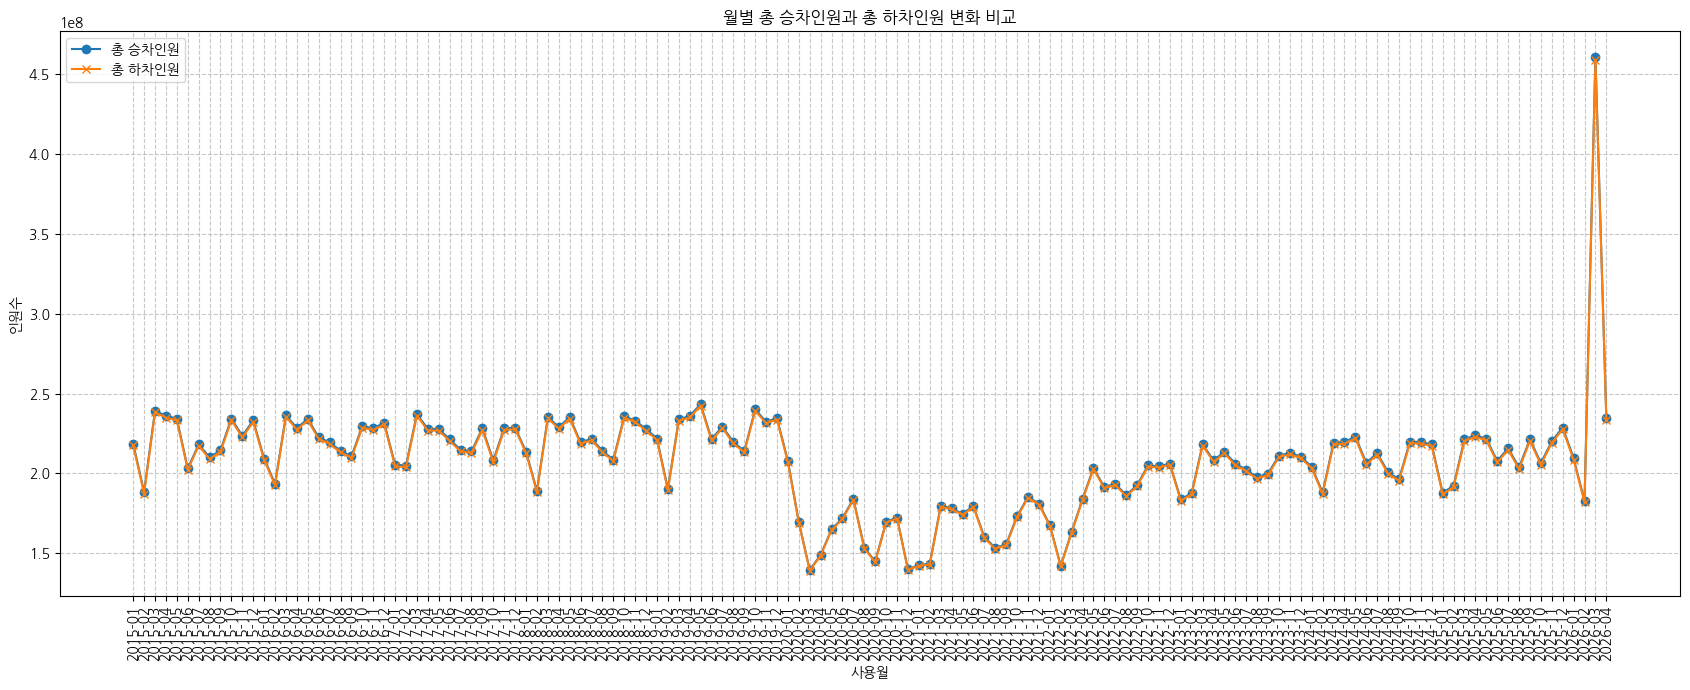

In [ ]:
# 월별 총 승차 및 하차 인원 집계
monthly_activity = df.groupby('사용월')[['총승차인원', '총하차인원']].sum().reset_index()

# '사용월'을 그래프에 적합한 형태로 변환 (예: 연-월)
monthly_activity['사용월_str'] = monthly_activity['사용월'].dt.strftime('%Y-%m')

# 그래프 그리기
plt.figure(figsize=(17, 7))
plt.plot(monthly_activity['사용월_str'], monthly_activity['총승차인원'], label='총 승차인원', marker='o')
plt.plot(monthly_activity['사용월_str'], monthly_activity['총하차인원'], label='총 하차인원', marker='x')

plt.title('월별 총 승차인원과 총 하차인원 변화 비교')
plt.xlabel('사용월')
plt.ylabel('인원수')
plt.xticks(rotation=90) # x축 레이블 회전
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

2026년 3월만 유독 높은 값을 가지고 있어 데이터에 문제가 있는지 확인합니다.

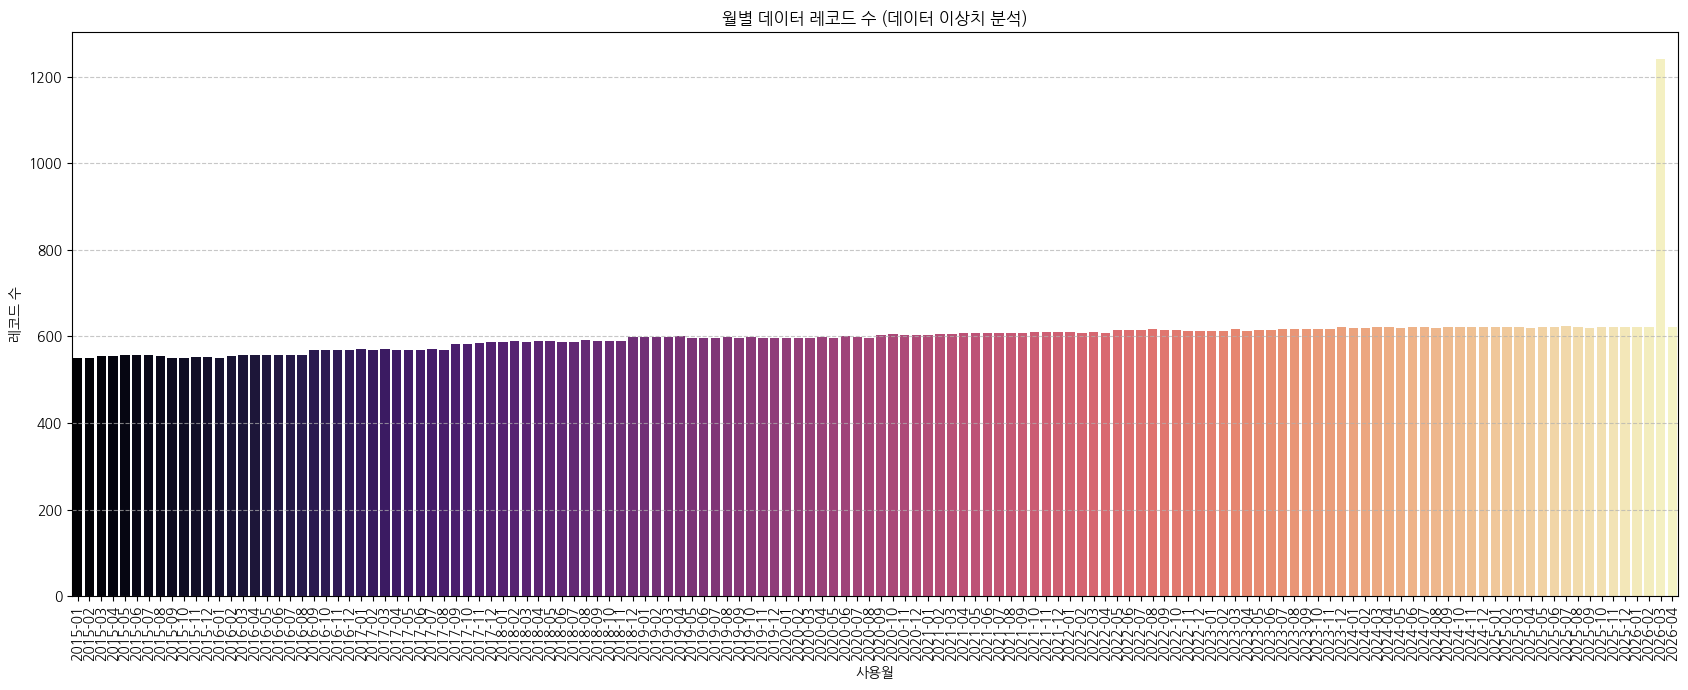


월별 레코드 수 상세:
         레코드_수  사용월_str
사용월                    
2025-07    623  2025-07
2025-08    622  2025-08
2025-09    620  2025-09
2025-10    622  2025-10
2025-11    622  2025-11
2025-12    621  2025-12
2026-01    621  2026-01
2026-02    621  2026-02
2026-03   1240  2026-03
2026-04    621  2026-04


In [ ]:
# 월별 레코드 수 계산
monthly_record_counts = df['사용월'].value_counts().sort_index().reset_index()
monthly_record_counts.columns = ['사용월', '레코드_수']

# '사용월'을 그래프에 적합한 문자열 형태로 변환
monthly_record_counts['사용월_str'] = monthly_record_counts['사용월'].dt.strftime('%Y-%m')

# 막대 그래프 그리기
plt.figure(figsize=(17, 7))
sns.barplot(x='사용월_str', y='레코드_수', data=monthly_record_counts, hue='사용월_str', legend=False, palette='magma')

plt.title('월별 데이터 레코드 수 (데이터 이상치 분석)')
plt.xlabel('사용월')
plt.ylabel('레코드 수')
plt.xticks(rotation=90) # x축 레이블 회전
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n월별 레코드 수 상세:")
print(monthly_record_counts.set_index('사용월').tail(10)) # 최근 10개월 데이터 출력

In [ ]:
df[df['사용월'] == '2026-03'].head(10)

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,총승차인원,총하차인원
621,2026-03,1호선,동대문,727,14,10804,1943,9387,6880,17052,...,1148,3292,1,351,0,0,0,0,424365,414885
622,2026-03,1호선,동대문,727,14,10804,1943,9387,6880,17052,...,1148,3292,1,351,0,0,0,0,424365,414885
623,2026-03,1호선,동묘앞,168,3,3038,1024,4442,5924,9248,...,125,2222,2,268,0,0,0,0,356264,367996
624,2026-03,1호선,동묘앞,168,3,3038,1024,4442,5924,9248,...,125,2222,2,268,0,0,0,0,356264,367996
625,2026-03,1호선,서울역,775,44,11465,11233,36857,65118,117965,...,3735,8125,15,227,0,0,0,0,2425098,2325542
626,2026-03,1호선,서울역,775,44,11465,11233,36857,65118,117965,...,3735,8125,15,227,0,0,0,0,2425098,2325542
627,2026-03,1호선,시청,163,1,1803,6051,3975,33718,8032,...,703,878,0,22,0,0,0,0,807659,819225
628,2026-03,1호선,시청,163,1,1803,6051,3975,33718,8032,...,703,878,0,22,0,0,0,0,807659,819225
629,2026-03,1호선,신설동,462,16,8676,2156,10811,9410,24447,...,591,2668,0,2,0,0,0,0,457038,439259
630,2026-03,1호선,신설동,462,16,8676,2156,10811,9410,24447,...,591,2668,0,2,0,0,0,0,457038,439259


값을 직접 확인해본 결과 중복 데이터가 존재하여 이를 삭제합니다.

In [5]:
df = df.drop_duplicates()

중복이 삭제되었는지 확인합니다.

In [ ]:
df[df['사용월'] == '2026-03'].head(10)

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,총승차인원,총하차인원
621,2026-03,1호선,동대문,727,14,10804,1943,9387,6880,17052,...,1148,3292,1,351,0,0,0,0,424365,414885
623,2026-03,1호선,동묘앞,168,3,3038,1024,4442,5924,9248,...,125,2222,2,268,0,0,0,0,356264,367996
625,2026-03,1호선,서울역,775,44,11465,11233,36857,65118,117965,...,3735,8125,15,227,0,0,0,0,2425098,2325542
627,2026-03,1호선,시청,163,1,1803,6051,3975,33718,8032,...,703,878,0,22,0,0,0,0,807659,819225
629,2026-03,1호선,신설동,462,16,8676,2156,10811,9410,24447,...,591,2668,0,2,0,0,0,0,457038,439259
631,2026-03,1호선,제기동,364,0,5177,2499,9194,10037,22454,...,185,1628,0,0,0,0,0,0,509737,523552
633,2026-03,1호선,종각,95,2,3899,6522,4648,38328,7615,...,1925,1235,0,2,0,0,0,0,1220392,1180456
635,2026-03,1호선,종로3가,149,7,3837,3919,4568,14716,7600,...,1594,2304,2,36,0,0,0,0,819118,735488
637,2026-03,1호선,종로5가,66,1,1838,4826,3439,20327,6596,...,395,1036,0,2,0,0,0,0,767500,751008
639,2026-03,1호선,청량리(서울시립대입구),1203,53,11190,2838,19865,10438,53645,...,361,4409,1,8,0,1,0,0,761762,758792


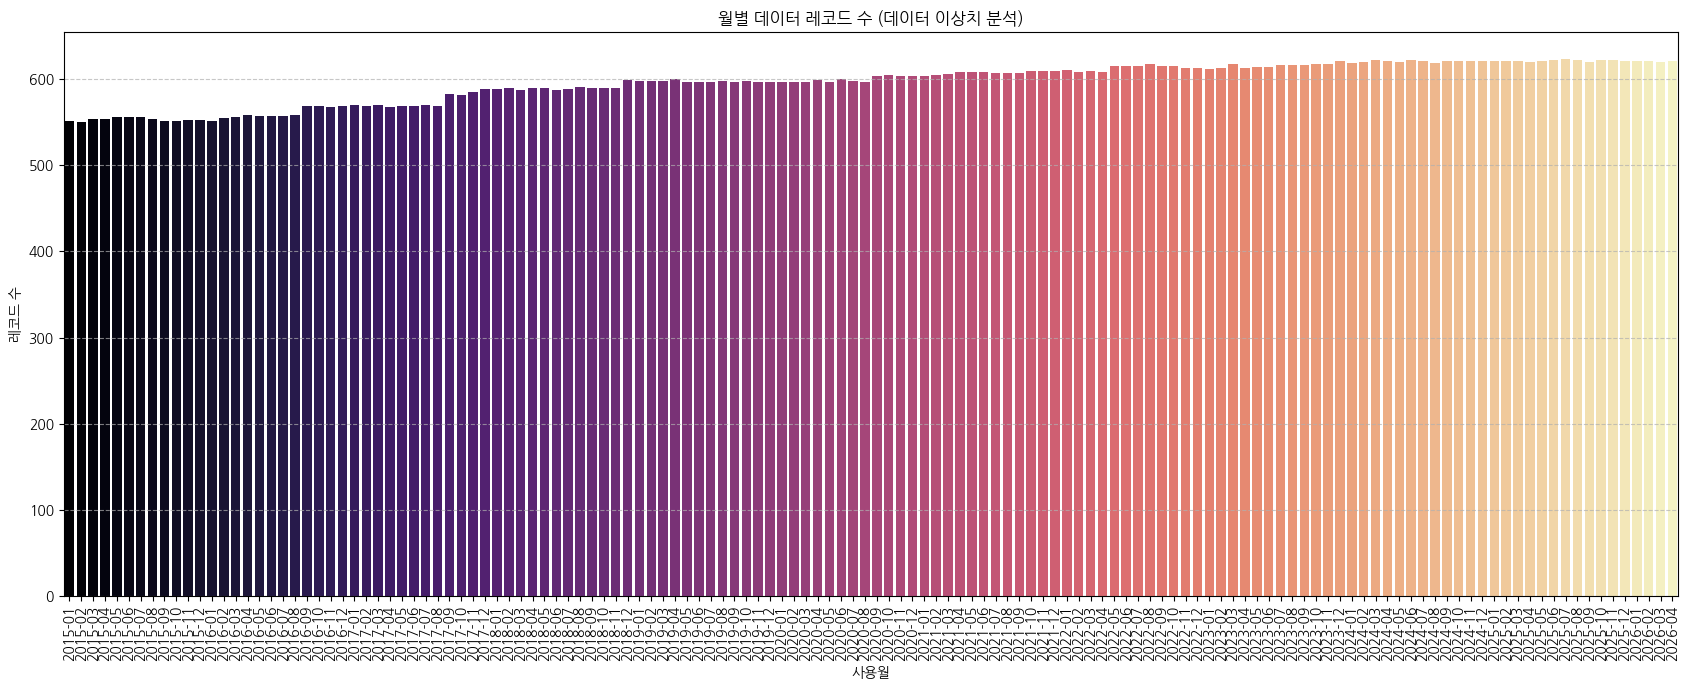


월별 레코드 수 상세:
         레코드_수  사용월_str
사용월                    
2025-07    623  2025-07
2025-08    622  2025-08
2025-09    620  2025-09
2025-10    622  2025-10
2025-11    622  2025-11
2025-12    621  2025-12
2026-01    621  2026-01
2026-02    621  2026-02
2026-03    620  2026-03
2026-04    621  2026-04


In [ ]:
# 월별 레코드 수 계산
monthly_record_counts = df['사용월'].value_counts().sort_index().reset_index()
monthly_record_counts.columns = ['사용월', '레코드_수']

# '사용월'을 그래프에 적합한 문자열 형태로 변환
monthly_record_counts['사용월_str'] = monthly_record_counts['사용월'].dt.strftime('%Y-%m')

# 막대 그래프 그리기
plt.figure(figsize=(17, 7))
sns.barplot(x='사용월_str', y='레코드_수', data=monthly_record_counts, hue='사용월_str', legend=False, palette='magma')

plt.title('월별 데이터 레코드 수 (데이터 이상치 분석)')
plt.xlabel('사용월')
plt.ylabel('레코드 수')
plt.xticks(rotation=90) # x축 레이블 회전
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n월별 레코드 수 상세:")
print(monthly_record_counts.set_index('사용월').tail(10)) # 최근 10개월 데이터 출력

### 년도-월별 변화

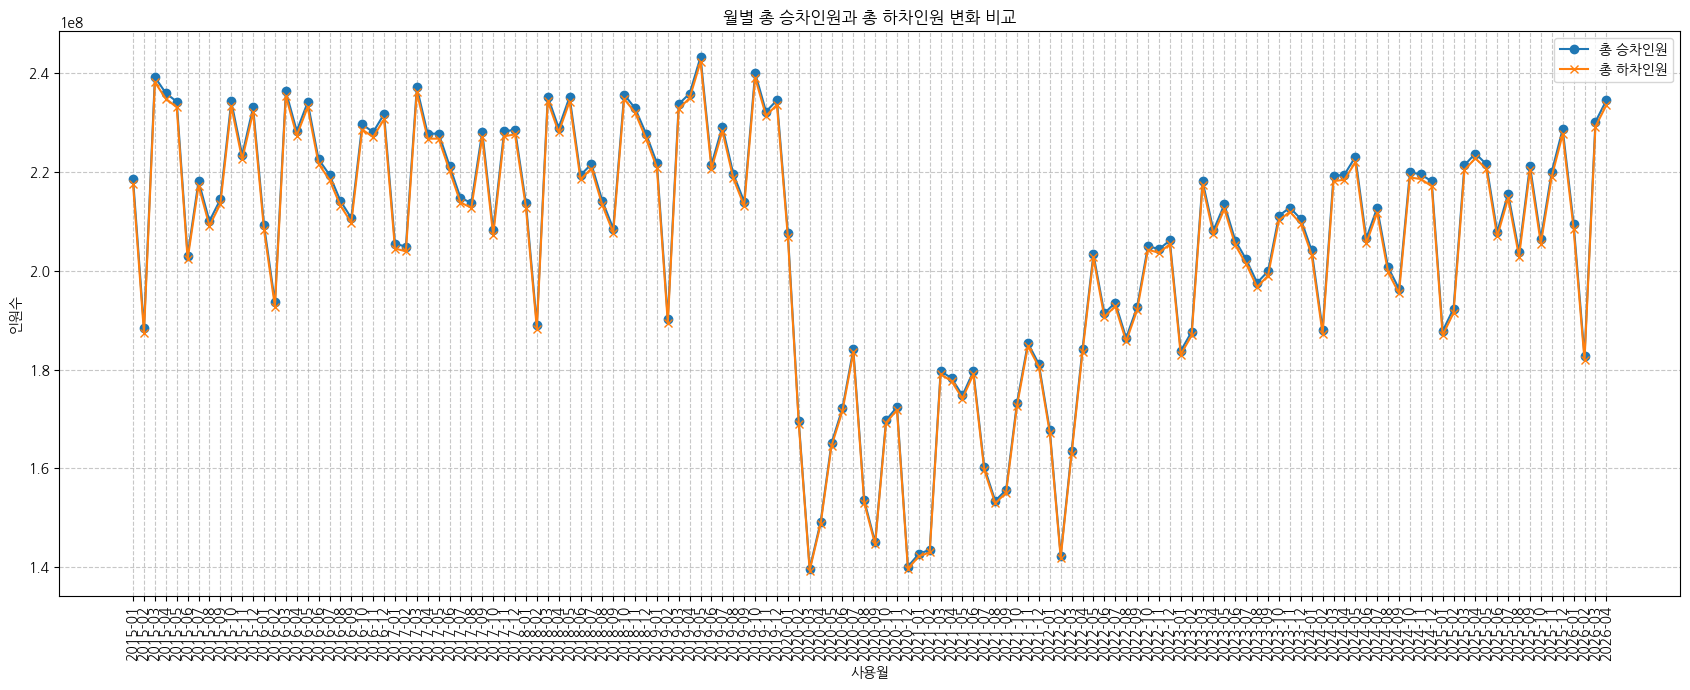

In [ ]:
# 월별 총 승차 및 하차 인원 집계
monthly_activity = df.groupby('사용월')[['총승차인원', '총하차인원']].sum().reset_index()

# '사용월'을 그래프에 적합한 형태로 변환 (예: 연-월)
monthly_activity['사용월_str'] = monthly_activity['사용월'].dt.strftime('%Y-%m')

# 그래프 그리기
plt.figure(figsize=(17, 7))
plt.plot(monthly_activity['사용월_str'], monthly_activity['총승차인원'], label='총 승차인원', marker='o')
plt.plot(monthly_activity['사용월_str'], monthly_activity['총하차인원'], label='총 하차인원', marker='x')

plt.title('월별 총 승차인원과 총 하차인원 변화 비교')
plt.xlabel('사용월')
plt.ylabel('인원수')
plt.xticks(rotation=90) # x축 레이블 회전
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

코로나의 영향으로 2020년 초에 급격히 감소했다가 천천히 회복하는 추세를 보입니다. 아직까지는 코로나 이전에 비해 낮은 인원수를 보입니다.

매년 1월에는 조금 낮았다가 3월에 올라오고, 다시 6월쯤 내려갔다가 10월에 올라오는 모습을 보입니다. 특히 2월은 급격히 감소하는 모습을 보입니다.

전반적으로 높고 낮아지는 시기가 대학교의 개학과 방학 시기와 유사한 모습을 보여줍니다. (개학에 높아지고 방학에 내려가는)

이어서 2월이 다른 월에 비해 너무 낮은 지표를 지속적으로 보여 이를 분석합니다.

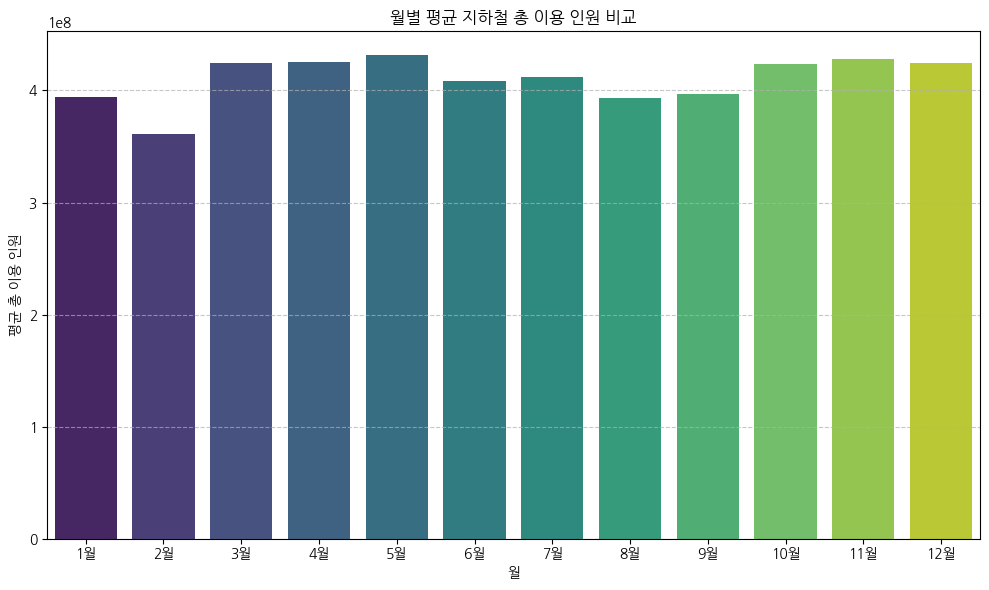

In [ ]:
monthly_activity['총이용인원'] = monthly_activity['총승차인원'] + monthly_activity['총하차인원']
monthly_activity['월'] = monthly_activity['사용월'].dt.month

# 월별 평균 총 이용 인원 계산
average_monthly_activity = monthly_activity.groupby('월')['총이용인원'].mean().reset_index()

# 월 이름을 한글로 매핑
month_names = {1: '1월', 2: '2월', 3: '3월', 4: '4월', 5: '5월', 6: '6월',
               7: '7월', 8: '8월', 9: '9월', 10: '10월', 11: '11월', 12: '12월'}
average_monthly_activity['월이름'] = average_monthly_activity['월'].map(month_names)

# 그래프 그리기
plt.figure(figsize=(10, 6))
sns.barplot(x='월이름', y='총이용인원', data=average_monthly_activity, palette='viridis', hue='월이름', legend=False)

plt.title('월별 평균 지하철 총 이용 인원 비교')
plt.xlabel('월')
plt.ylabel('평균 총 이용 인원')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
pd.set_option('display.float_format', '{:,.0f}'.format)
print(monthly_activity.groupby('월')['총이용인원'].mean())
pd.reset_option('display.float_format')

월
1    394,574,629
2    361,367,025
3    424,794,099
4    424,929,050
5    431,173,554
6    408,609,612
7    412,233,751
8    393,256,738
9    396,830,608
10   423,460,264
11   428,219,240
12   424,721,945
Name: 총이용인원, dtype: float64


In [ ]:
print(f"월평균 이용 인원: {round(monthly_activity.groupby('월')['총이용인원'].mean().mean())}")

월평균 이용 인원: 410347543


2026년 기준 서울 지하철 하루 평균 이용 인원이 대략 700만(계산의 편의를 위해 반올림함) 명 정도입니다. (출처: [서울지하철 하루 평균 669만명 탄다…가장 붐빈 역 ‘잠실역’](https://www.joongang.co.kr/article/25410566), [서울지하철 하루 669만명 탔다…가장 붐비는 역은 어디?](https://www.hankyung.com/article/2026031008417))

월평균 이용 인원이 4억 1천만 정도이니, 2월은 그에 비해 5천만 정도의 차이가 발생하고 있다고 볼 수 있습니다. (2월은 3억 6천만)

이는 대략 7\~8일 정도의 차이로, 2월이 다른 월에 비해 대략 2\~3일 정도 적다는 점과 설날 연휴로 인해 줄어든 인원수까지 고려하면 어느 정도 납득 가능한 변화입니다.

### 역 분석

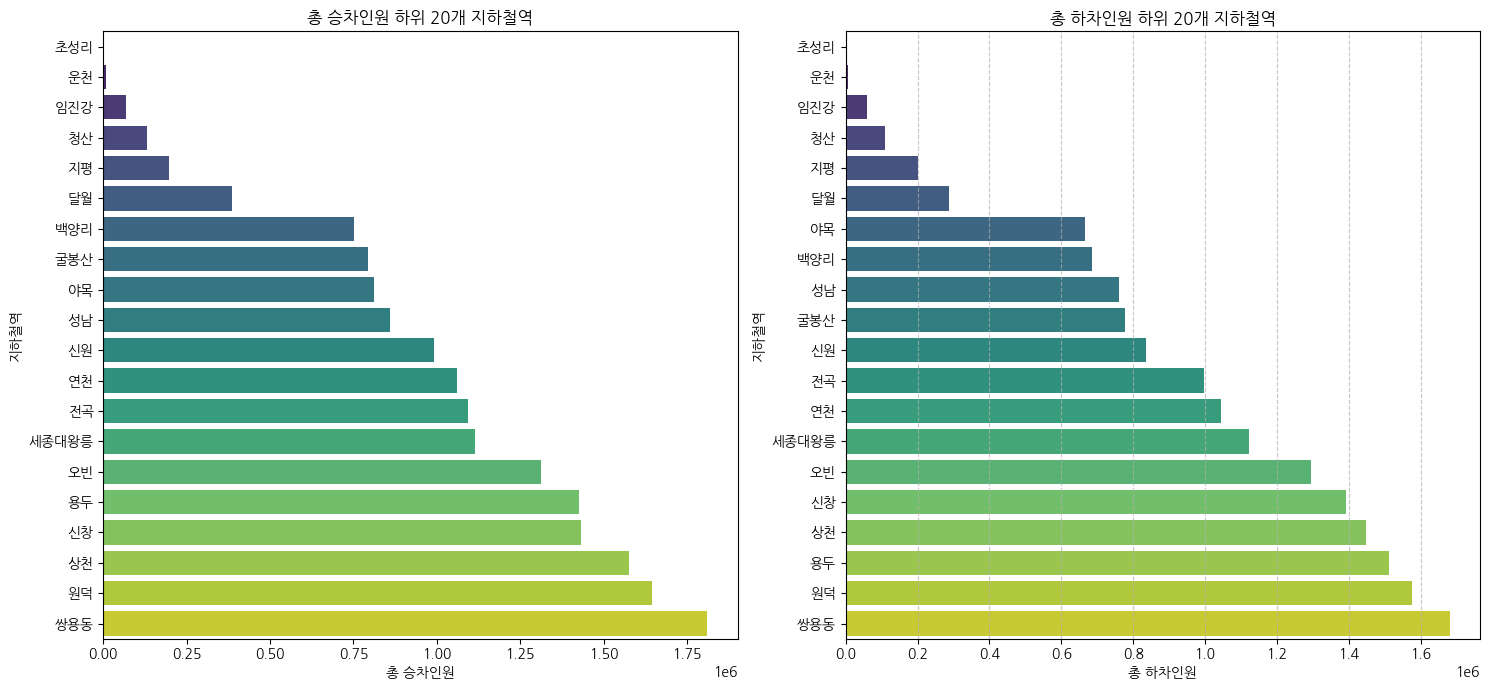

In [ ]:
# 지하철역별 총승차인원 집계
station_boarding = df.groupby('지하철역')['총승차인원'].sum().reset_index()

top_10_stations = station_boarding.sort_values(by='총승차인원', ascending=True).head(20)

# 막대 그래프 그리기
plt.figure(figsize=(15, 7))

plt.subplot(121)
sns.barplot(x='총승차인원', y='지하철역', data=top_10_stations, palette='viridis', hue='지하철역', legend=False)

plt.title('총 승차인원 하위 20개 지하철역')
plt.xlabel('총 승차인원')
plt.ylabel('지하철역')


station_boarding = df.groupby('지하철역')['총하차인원'].sum().reset_index()

top_10_stations = station_boarding.sort_values(by='총하차인원', ascending=True).head(20)

plt.subplot(122)
sns.barplot(x='총하차인원', y='지하철역', data=top_10_stations, palette='viridis', hue='지하철역', legend=False)

plt.title('총 하차인원 하위 20개 지하철역')
plt.xlabel('총 하차인원')
plt.ylabel('지하철역')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

초성리와 운천의 인원이 지나치게 적어 원인에 대해 조사했습니다.

In [ ]:
df[df['지하철역'] == '초성리']

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,총승차인원,총하차인원
18403,2023-12,경원선,초성리,32,7,48,6,67,88,161,...,0,34,0,0,0,0,0,0,2247,2067


초성리의 경우 주민들의 건의로 인해 이름이 청산으로 변경되었다고 합니다. (출처: http://www.ycgmnews.com/news/articleView.html?idxno=29237)

In [ ]:
jamsil_data = df[df['지하철역'] == '청산']
if not jamsil_data.empty:
    start_year = jamsil_data['사용월'].dt.year.min()
    end_year = jamsil_data['사용월'].dt.year.max()
    print(f"'청산'역 데이터는 {start_year}년부터 {end_year}년까지 존재합니다.")
else:
    print("'청산'역 데이터가 존재하지 않습니다.")

'청산'역 데이터는 2024년부터 2026년까지 존재합니다.


In [ ]:
df[df['지하철역'] == '청산'].head()

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,총승차인원,총하차인원
396,2026-04,경원선,청산,0,0,92,5,146,187,628,...,3,71,0,0,0,0,0,0,5053,4454
1411,2026-03,경원선,청산,0,0,89,4,156,216,563,...,0,60,0,0,0,0,0,0,4817,4093
2257,2026-02,경원선,청산,0,0,69,4,104,126,438,...,2,59,0,0,0,0,0,0,3879,3163
2877,2026-01,경원선,청산,0,0,91,4,119,125,530,...,0,55,0,0,0,0,0,0,4137,3352
3498,2025-12,경원선,청산,0,0,78,0,96,142,578,...,2,92,0,0,0,0,0,0,4374,3656


데이터를 확인해 보면 청산은 정상적으로 집계되고 있습니다.

In [ ]:
df[df['지하철역'] == '운천'].head()

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,총승차인원,총하차인원
417,2026-04,경의선,운천,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,122,139
1453,2026-03,경의선,운천,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,155,127
2278,2026-02,경의선,운천,0,0,0,0,2,2,8,...,0,0,0,0,0,0,0,0,139,117
2899,2026-01,경의선,운천,0,0,0,0,2,2,4,...,0,0,0,0,0,0,0,0,168,133
3520,2025-12,경의선,운천,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,179,140


In [ ]:
jamsil_data = df[df['지하철역'] == '운천']
if not jamsil_data.empty:
    start_year = jamsil_data['사용월'].dt.year.min()
    end_year = jamsil_data['사용월'].dt.year.max()
    print(f"'운천'역 데이터는 {start_year}년부터 {end_year}년까지 존재합니다.")
else:
    print("'운천'역 데이터가 존재하지 않습니다.")

'운천'역 데이터는 2022년부터 2026년까지 존재합니다.


운천의 경우 집계는 되고 있지만 이용하는 인원 자체가 적은 경우입니다.

경의선의 경우 배차 간격이 긴 편인데다, 운천역 자체가 외진 곳에 있다보니 접근성이 떨어져 이용 인원이 적은 것으로 보입니다.

카카오 지하철로 확인해 본 결과 평일의 경우 아예 첫차와 막차를 제외하고는 운행하지 않습니다.

![운천역 이미지](https://i.namu.wiki/i/PZz3AxSwUoyrj3xNYyrJszjph1W_ueHYogIKheJAOG4aH-_gTYpKiiO6yAfgLF3ay_a0tCYxmBZduRlc2NPbiw.webp)

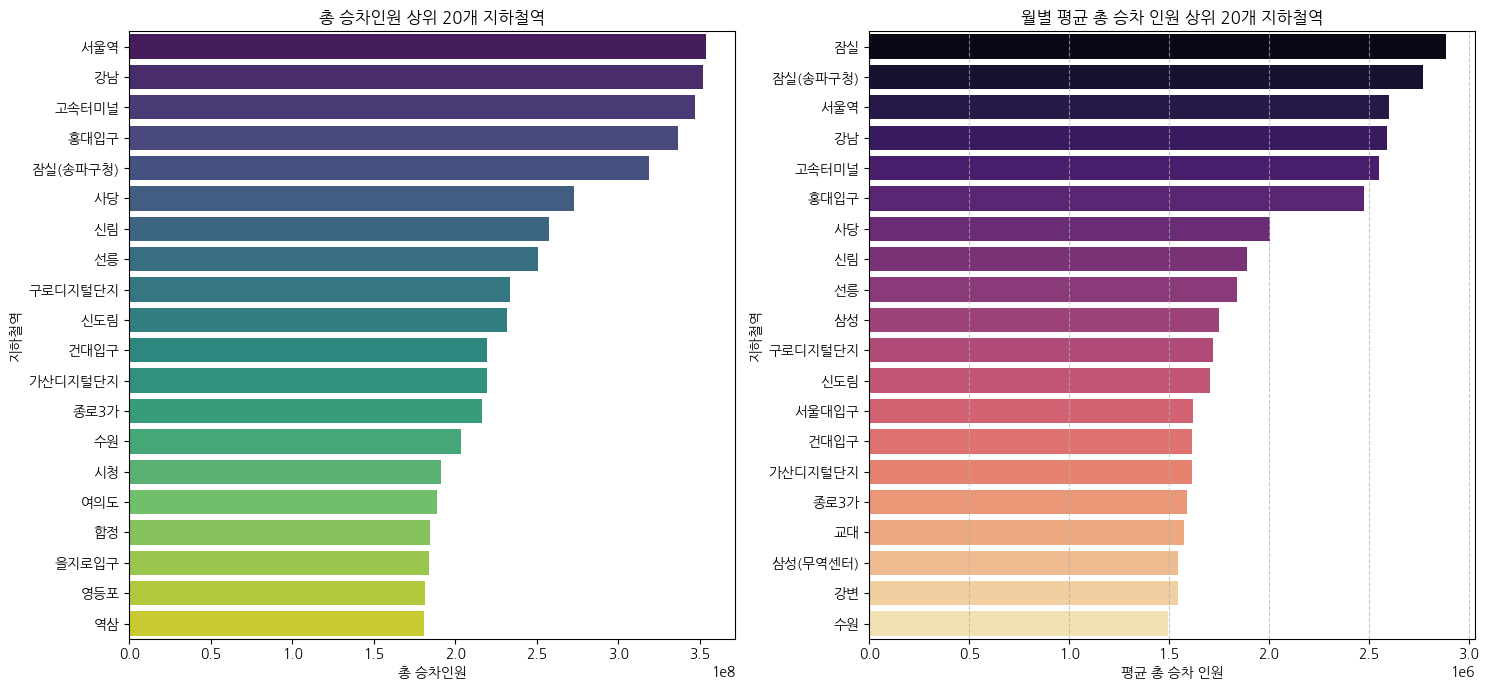

In [ ]:
# 지하철역별 총승차인원 집계
station_boarding = df.groupby('지하철역')['총승차인원'].sum().reset_index()

# 총승차인원 기준으로 내림차순 정렬 후 상위 20개 역 선택
top_10_stations = station_boarding.sort_values(by='총승차인원', ascending=False).head(20)

# 막대 그래프 그리기
plt.figure(figsize=(15, 7))

plt.subplot(121)
sns.barplot(x='총승차인원', y='지하철역', data=top_10_stations, palette='viridis', hue='지하철역', legend=False)

plt.title('총 승차인원 상위 20개 지하철역')
plt.xlabel('총 승차인원')
plt.ylabel('지하철역')


# 1. 먼저 같은 달, 같은 역의 여러 노선 데이터를 합칩니다.
monthly_station_sum = df.groupby(['사용월', '지하철역'])['총승차인원'].sum().reset_index()

# 2. 합쳐진 데이터를 바탕으로 역별 월평균을 구합니다.
correct_average = monthly_station_sum.groupby('지하철역')['총승차인원'].mean().reset_index()

# 평균 총 이용 인원 기준으로 내림차순 정렬 후 상위 20개 역 선택
top_10_average_stations = correct_average.sort_values(by='총승차인원', ascending=False).head(20)

# 막대 그래프 그리기
plt.subplot(122)
sns.barplot(x='총승차인원', y='지하철역', data=top_10_average_stations, palette='magma', hue='지하철역', legend=False)

plt.title('월별 평균 총 승차 인원 상위 20개 지하철역')
plt.xlabel('평균 총 승차 인원')
plt.ylabel('지하철역')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

누적 승차 인원과 월평균 승차 인원을 비교한 결과입니다. 순위에 변화가 있는데, 특히 잠실이 누적에는 없었는데 월평균은 1위가 되었습니다.

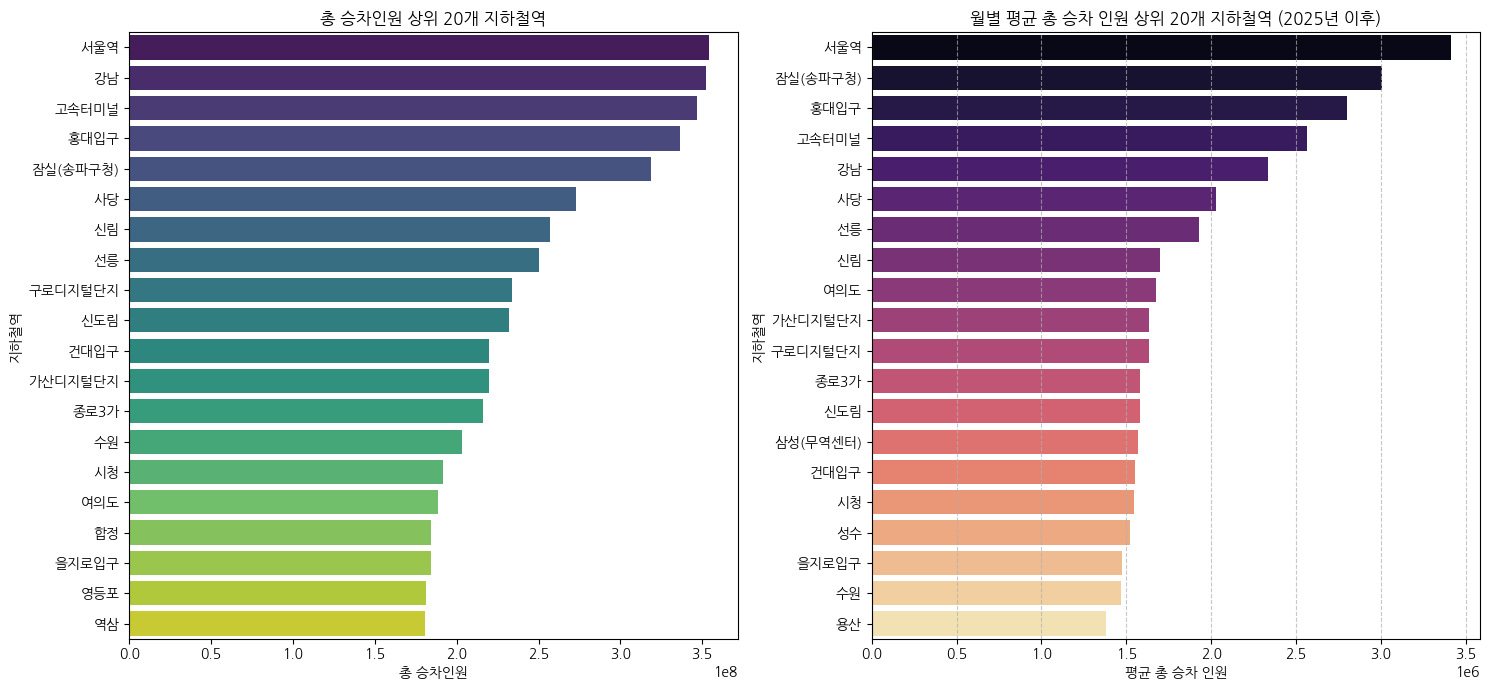

In [ ]:
df_2025 = df[df["사용월"].dt.year >= 2025]

# 지하철역별 총승차인원 집계
station_boarding = df.groupby('지하철역')['총승차인원'].sum().reset_index()

# 총승차인원 기준으로 내림차순 정렬 후 상위 20개 역 선택
top_10_stations = station_boarding.sort_values(by='총승차인원', ascending=False).head(20)

# 막대 그래프 그리기
plt.figure(figsize=(15, 7))

plt.subplot(121)
sns.barplot(x='총승차인원', y='지하철역', data=top_10_stations, palette='viridis', hue='지하철역', legend=False)

plt.title('총 승차인원 상위 20개 지하철역')
plt.xlabel('총 승차인원')
plt.ylabel('지하철역')


# 1. 먼저 같은 달, 같은 역의 여러 노선 데이터를 합칩니다.
monthly_station_sum = df_2025.groupby(['사용월', '지하철역'])['총승차인원'].sum().reset_index()

# 2. 합쳐진 데이터를 바탕으로 역별 월평균을 구합니다.
correct_average = monthly_station_sum.groupby('지하철역')['총승차인원'].mean().reset_index()

# 평균 총 이용 인원 기준으로 내림차순 정렬 후 상위 20개 역 선택
top_10_average_stations = correct_average.sort_values(by='총승차인원', ascending=False).head(20)

# 막대 그래프 그리기
plt.subplot(122)
sns.barplot(x='총승차인원', y='지하철역', data=top_10_average_stations, palette='magma', hue='지하철역', legend=False)

plt.title('월별 평균 총 승차 인원 상위 20개 지하철역 (2025년 이후)')
plt.xlabel('평균 총 승차 인원')
plt.ylabel('지하철역')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

누적과 월평균 모두 범위를 2025년 이후로 좁히자 두 지표가 비슷한 순위를 가지게 됩니다.

잠실의 경우 2025년 이후로 갑자기 사라져서 원인을 분석합니다.

In [ ]:
# 평균 총 승차 인원 기준 내림차순 정렬
ranked_stations = df.groupby('지하철역')['총승차인원'].sum().reset_index().sort_values(
    by='총승차인원',
    ascending=False
).reset_index(drop=True)

# 순위 컬럼 추가 (1위부터 시작)
ranked_stations['순위'] = ranked_stations.index + 1

# 서울역 순위 확인
seoul_station_rank = ranked_stations[ranked_stations['지하철역'] == '잠실']

print(seoul_station_rank)

    지하철역     총승차인원   순위
151   잠실  60636349  152


In [ ]:
df_2025 = df[df["사용월"].dt.year >= 2025]

# 평균 총 승차 인원 기준 내림차순 정렬
ranked_stations = df_2025.groupby('지하철역')['총승차인원'].sum().reset_index().sort_values(
    by='총승차인원',
    ascending=False
).reset_index(drop=True)

# 순위 컬럼 추가 (1위부터 시작)
ranked_stations['순위'] = ranked_stations.index + 1

# 서울역 순위 확인
seoul_station_rank = ranked_stations[ranked_stations['지하철역'] == '잠실']

print(seoul_station_rank)

Empty DataFrame
Columns: [지하철역, 총승차인원, 순위]
Index: []


In [ ]:
jamsil_data = df[df['지하철역'] == '잠실']
if not jamsil_data.empty:
    start_year = jamsil_data['사용월'].dt.year.min()
    end_year = jamsil_data['사용월'].dt.year.max()
    print(f"'잠실'역 데이터는 {start_year}년부터 {end_year}년까지 존재합니다.")
else:
    print("'잠실'역 데이터가 존재하지 않습니다.")

'잠실'역 데이터는 2015년부터 2016년까지 존재합니다.


In [ ]:
jamsil_data = df[df['지하철역'] == '잠실(송파구청)']
if not jamsil_data.empty:
    start_year = jamsil_data['사용월'].dt.year.min()
    end_year = jamsil_data['사용월'].dt.year.max()
    print(f"'잠실(송파구청)'역 데이터는 {start_year}년부터 {end_year}년까지 존재합니다.")
else:
    print("'잠실(송파구청)'역 데이터가 존재하지 않습니다.")

'잠실(송파구청)'역 데이터는 2016년부터 2026년까지 존재합니다.


확인해본 결과 초성리와 비슷하게 잠실은 2016년 이후로 잠실(송파구청)으로 명칭이 변경되었습니다.

#### 역 세부 분석

누적 및 월평균 이용 인원이 많은 상위 역 중 일부를 분석합니다.

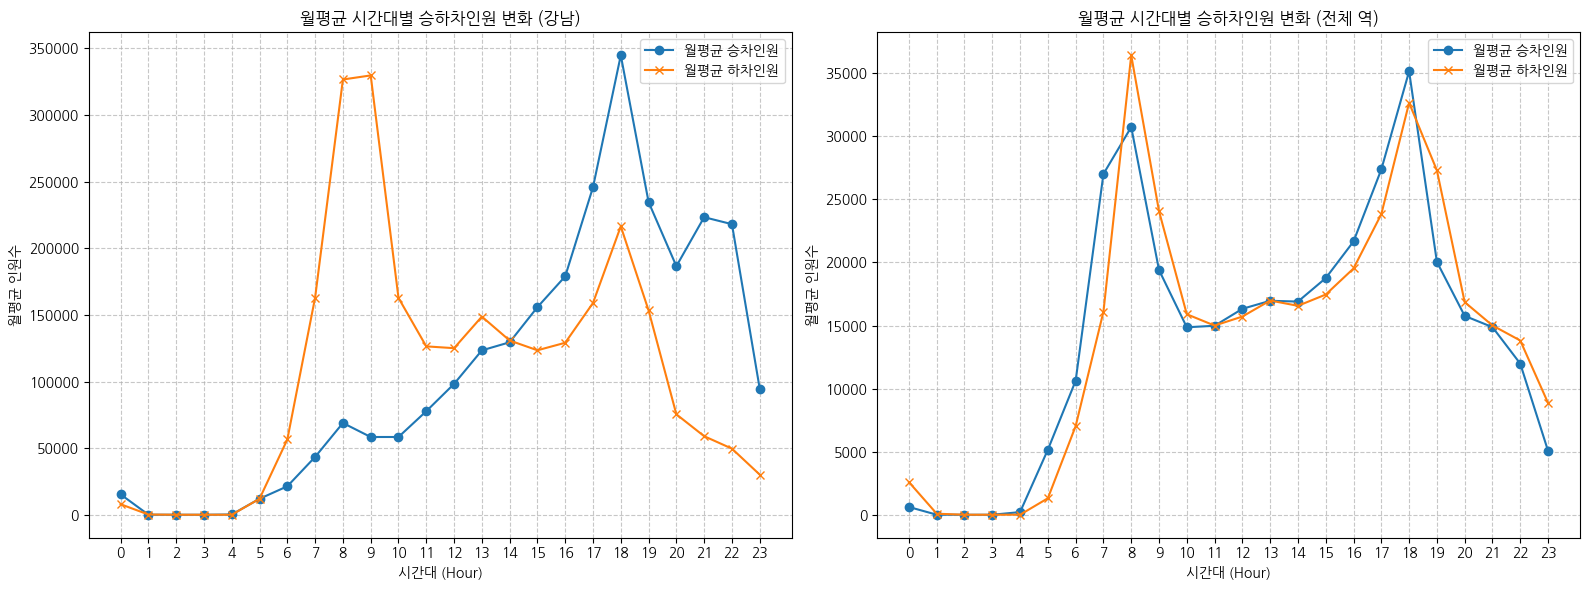

In [ ]:
jamsil_df = df[df['지하철역'] == '강남']

# 시간대별 승차 및 하차 인원 평균을 저장할 딕셔너리 초기화
hourly_ride_averages_jamsil = {}
hourly_alight_averages_jamsil = {}

# 00시부터 23시까지 각 시간대별 승차/하차 인원 평균 계산
for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in jamsil_df.columns:
        hourly_ride_averages_jamsil[i] = jamsil_df[ride_col].mean()
    else:
        hourly_ride_averages_jamsil[i] = 0

    if alight_col in jamsil_df.columns:
        hourly_alight_averages_jamsil[i] = jamsil_df[alight_col].mean()
    else:
        hourly_alight_averages_jamsil[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_jamsil = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_jamsil[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_jamsil[hour] for hour in range(24)]
})

# 그래프 그리기
plt.figure(figsize=(16, 6))

plt.subplot(121)
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (강남)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


# 전체 역에 대한 월평균 시간대별 승차 및 하차 인원 계산
hourly_ride_averages_all = {}
hourly_alight_averages_all = {}

for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in df.columns:
        hourly_ride_averages_all[i] = df[ride_col].mean()
    else:
        hourly_ride_averages_all[i] = 0

    if alight_col in df.columns:
        hourly_alight_averages_all[i] = df[alight_col].mean()
    else:
        hourly_alight_averages_all[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_all = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_all[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_all[hour] for hour in range(24)]
})

# 그래프 그리기
plt.subplot(122)
plt.plot(hourly_activity_df_all['시간'], hourly_activity_df_all['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_all['시간'], hourly_activity_df_all['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (전체 역)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

강남역은 매우 독특한 지표를 보여줍니다.

시간대별로 하차인원과 승차인원 간의 격차가 매우 분명하여 오전 5시 이후부터 오후 2시까지는 하차인원이 많고 오후 2시 이후부터 새벽 1시까지는 승차인원이 많습니다.

피크 시간대(오전 8시, 오후 6시)가 아닌 경우 승차 인원과 하차 인원이 비슷한 다른 역들에 비해 상당히 비교되는 점입니다.

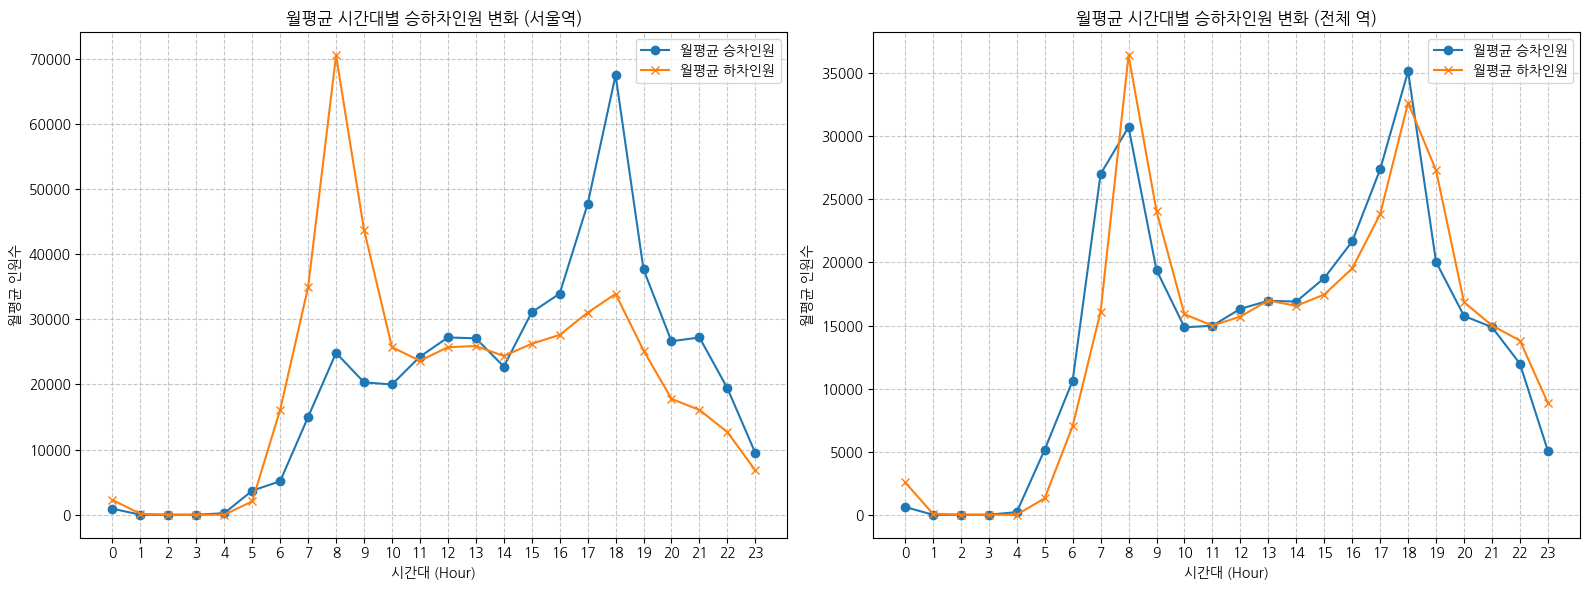

In [ ]:
jamsil_df = df[df['지하철역'] == '서울역']

# 시간대별 승차 및 하차 인원 평균을 저장할 딕셔너리 초기화
hourly_ride_averages_jamsil = {}
hourly_alight_averages_jamsil = {}

# 00시부터 23시까지 각 시간대별 승차/하차 인원 평균 계산
for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in jamsil_df.columns:
        hourly_ride_averages_jamsil[i] = jamsil_df[ride_col].mean()
    else:
        hourly_ride_averages_jamsil[i] = 0

    if alight_col in jamsil_df.columns:
        hourly_alight_averages_jamsil[i] = jamsil_df[alight_col].mean()
    else:
        hourly_alight_averages_jamsil[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_jamsil = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_jamsil[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_jamsil[hour] for hour in range(24)]
})

# 그래프 그리기
plt.figure(figsize=(16, 6))

plt.subplot(121)
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (서울역)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


# 전체 역에 대한 월평균 시간대별 승차 및 하차 인원 계산
hourly_ride_averages_all = {}
hourly_alight_averages_all = {}

for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in df.columns:
        hourly_ride_averages_all[i] = df[ride_col].mean()
    else:
        hourly_ride_averages_all[i] = 0

    if alight_col in df.columns:
        hourly_alight_averages_all[i] = df[alight_col].mean()
    else:
        hourly_alight_averages_all[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_all = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_all[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_all[hour] for hour in range(24)]
})

# 그래프 그리기
plt.subplot(122)
plt.plot(hourly_activity_df_all['시간'], hourly_activity_df_all['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_all['시간'], hourly_activity_df_all['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (전체 역)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

서울역은 피크 시간대를 제외하고서는 비교적 평범한 지표를 보여줍니다.

출근 시간(오전 8시)쯤에는 하차 인원이 많고, 퇴근 시간(오후 6시)쯤에는 승차 인원이 많습니다.

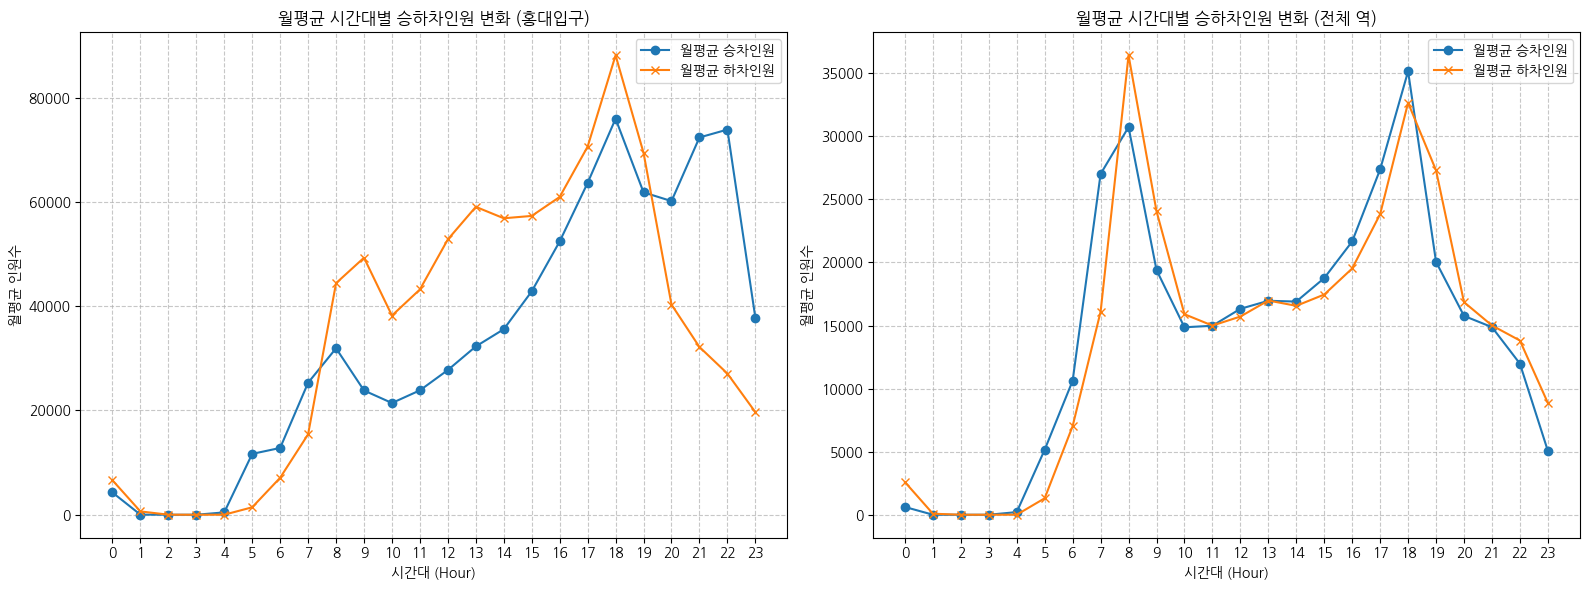

In [ ]:
jamsil_df = df[df['지하철역'] == '홍대입구']

# 시간대별 승차 및 하차 인원 평균을 저장할 딕셔너리 초기화
hourly_ride_averages_jamsil = {}
hourly_alight_averages_jamsil = {}

# 00시부터 23시까지 각 시간대별 승차/하차 인원 평균 계산
for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in jamsil_df.columns:
        hourly_ride_averages_jamsil[i] = jamsil_df[ride_col].mean()
    else:
        hourly_ride_averages_jamsil[i] = 0

    if alight_col in jamsil_df.columns:
        hourly_alight_averages_jamsil[i] = jamsil_df[alight_col].mean()
    else:
        hourly_alight_averages_jamsil[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_jamsil = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_jamsil[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_jamsil[hour] for hour in range(24)]
})

# 그래프 그리기
plt.figure(figsize=(16, 6))

plt.subplot(121)
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (홍대입구)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


# 전체 역에 대한 월평균 시간대별 승차 및 하차 인원 계산
hourly_ride_averages_all = {}
hourly_alight_averages_all = {}

for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in df.columns:
        hourly_ride_averages_all[i] = df[ride_col].mean()
    else:
        hourly_ride_averages_all[i] = 0

    if alight_col in df.columns:
        hourly_alight_averages_all[i] = df[alight_col].mean()
    else:
        hourly_alight_averages_all[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_all = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_all[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_all[hour] for hour in range(24)]
})

# 그래프 그리기
plt.subplot(122)
plt.plot(hourly_activity_df_all['시간'], hourly_activity_df_all['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_all['시간'], hourly_activity_df_all['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (전체 역)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

홍대입구역도 상당히 독특한 지표를 보여줍니다.

다른 역과는 달리 천천히 승하차 인원이 증가하다가 오후 6시에 피크를 찍고 내려오는 것을 볼 수 있습니다.

또한 오전 8시 이후부터 오후 7시까지는 꾸준히 하차 인원이 많다가 이후에 가파르게 떨어지고, 승차 인원은 어느 정도 유지되다가 떨어집니다.

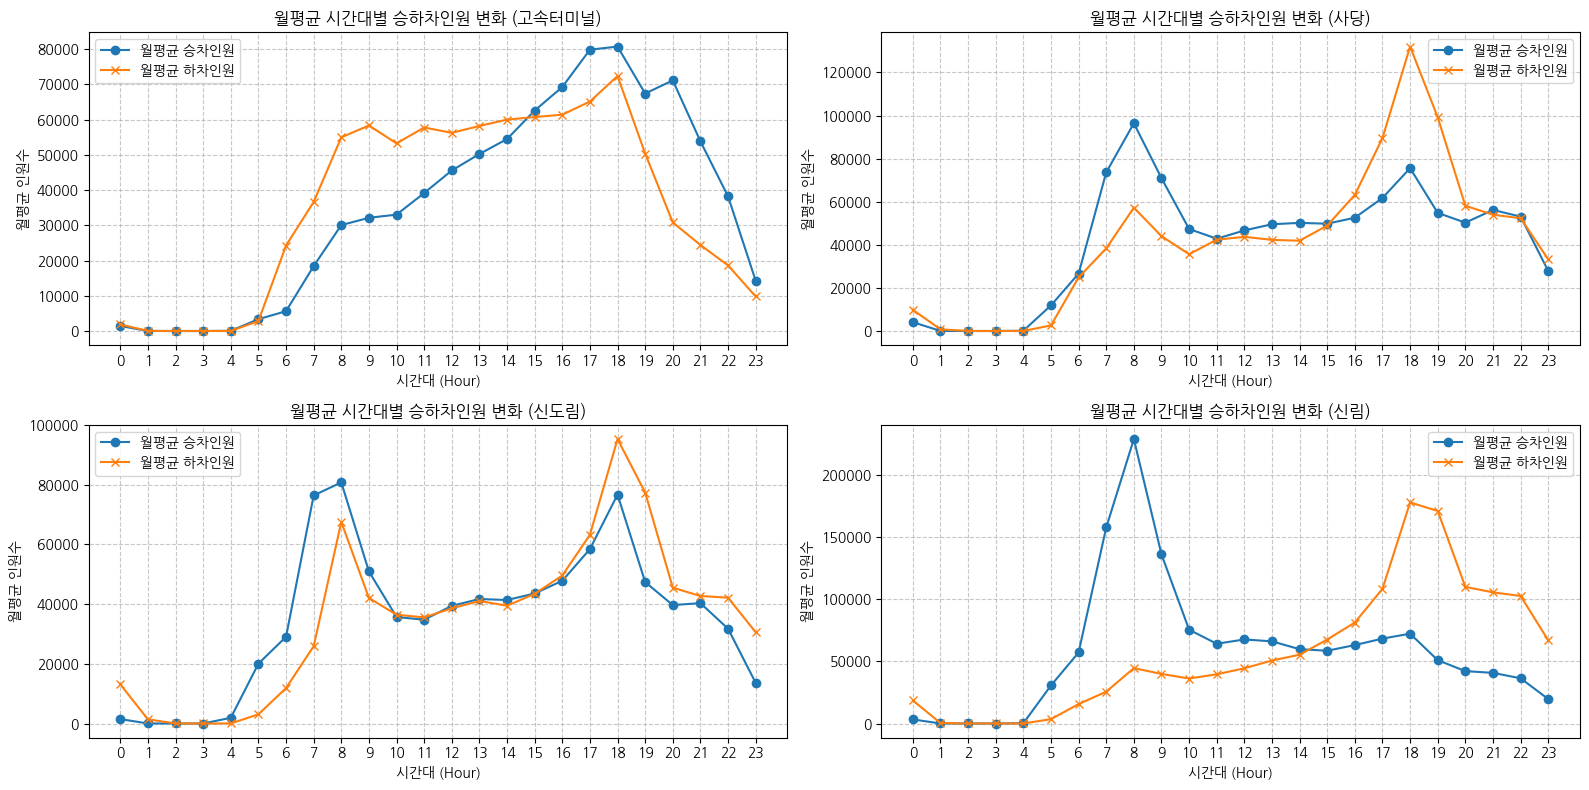

In [ ]:
jamsil_df = df[df['지하철역'] == '고속터미널']

# 시간대별 승차 및 하차 인원 평균을 저장할 딕셔너리 초기화
hourly_ride_averages_jamsil = {}
hourly_alight_averages_jamsil = {}

# 00시부터 23시까지 각 시간대별 승차/하차 인원 평균 계산
for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in jamsil_df.columns:
        hourly_ride_averages_jamsil[i] = jamsil_df[ride_col].mean()
    else:
        hourly_ride_averages_jamsil[i] = 0

    if alight_col in jamsil_df.columns:
        hourly_alight_averages_jamsil[i] = jamsil_df[alight_col].mean()
    else:
        hourly_alight_averages_jamsil[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_jamsil = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_jamsil[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_jamsil[hour] for hour in range(24)]
})

# 그래프 그리기
plt.figure(figsize=(16, 8))

plt.subplot(221)
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (고속터미널)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

jamsil_df = df[df['지하철역'] == '사당']

# 시간대별 승차 및 하차 인원 평균을 저장할 딕셔너리 초기화
hourly_ride_averages_jamsil = {}
hourly_alight_averages_jamsil = {}

# 00시부터 23시까지 각 시간대별 승차/하차 인원 평균 계산
for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in jamsil_df.columns:
        hourly_ride_averages_jamsil[i] = jamsil_df[ride_col].mean()
    else:
        hourly_ride_averages_jamsil[i] = 0

    if alight_col in jamsil_df.columns:
        hourly_alight_averages_jamsil[i] = jamsil_df[alight_col].mean()
    else:
        hourly_alight_averages_jamsil[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_jamsil = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_jamsil[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_jamsil[hour] for hour in range(24)]
})

# 그래프 그리기
plt.subplot(222)
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (사당)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


jamsil_df = df[df['지하철역'] == '신도림']

# 시간대별 승차 및 하차 인원 평균을 저장할 딕셔너리 초기화
hourly_ride_averages_jamsil = {}
hourly_alight_averages_jamsil = {}

# 00시부터 23시까지 각 시간대별 승차/하차 인원 평균 계산
for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in jamsil_df.columns:
        hourly_ride_averages_jamsil[i] = jamsil_df[ride_col].mean()
    else:
        hourly_ride_averages_jamsil[i] = 0

    if alight_col in jamsil_df.columns:
        hourly_alight_averages_jamsil[i] = jamsil_df[alight_col].mean()
    else:
        hourly_alight_averages_jamsil[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_jamsil = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_jamsil[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_jamsil[hour] for hour in range(24)]
})

# 그래프 그리기
plt.subplot(223)
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (신도림)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


jamsil_df = df[df['지하철역'] == '신림']

# 전체 역에 대한 월평균 시간대별 승차 및 하차 인원 계산
hourly_ride_averages_all = {}
hourly_alight_averages_all = {}

for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in jamsil_df.columns:
        hourly_ride_averages_all[i] = jamsil_df[ride_col].mean()
    else:
        hourly_ride_averages_all[i] = 0

    if alight_col in jamsil_df.columns:
        hourly_alight_averages_all[i] = jamsil_df[alight_col].mean()
    else:
        hourly_alight_averages_all[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_all = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_all[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_all[hour] for hour in range(24)]
})

# 그래프 그리기
plt.subplot(224)
plt.plot(hourly_activity_df_all['시간'], hourly_activity_df_all['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_all['시간'], hourly_activity_df_all['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (신림)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

외에도 다양한 역을 분석했는데 신도림을 제외하고는 모두 독특한 지표를 보였습니다.

전체적으로 출퇴근에 영향을 받는 역은 출근 시간과 퇴근 시간에 가장 높고, 그렇지 않은 역은 천천히 올라갔다가 퇴근 시간쯤 내려가는 것을 볼 수 있었습니다.

또한 출근지와 같이 회사 건물이나 놀거리가 있는 역의 경우 출근 시간에 하차 인원이 많았고, 그렇지 않은 곳은 출근 시간에 승차 인원이 많았습니다.

### 호선 분석

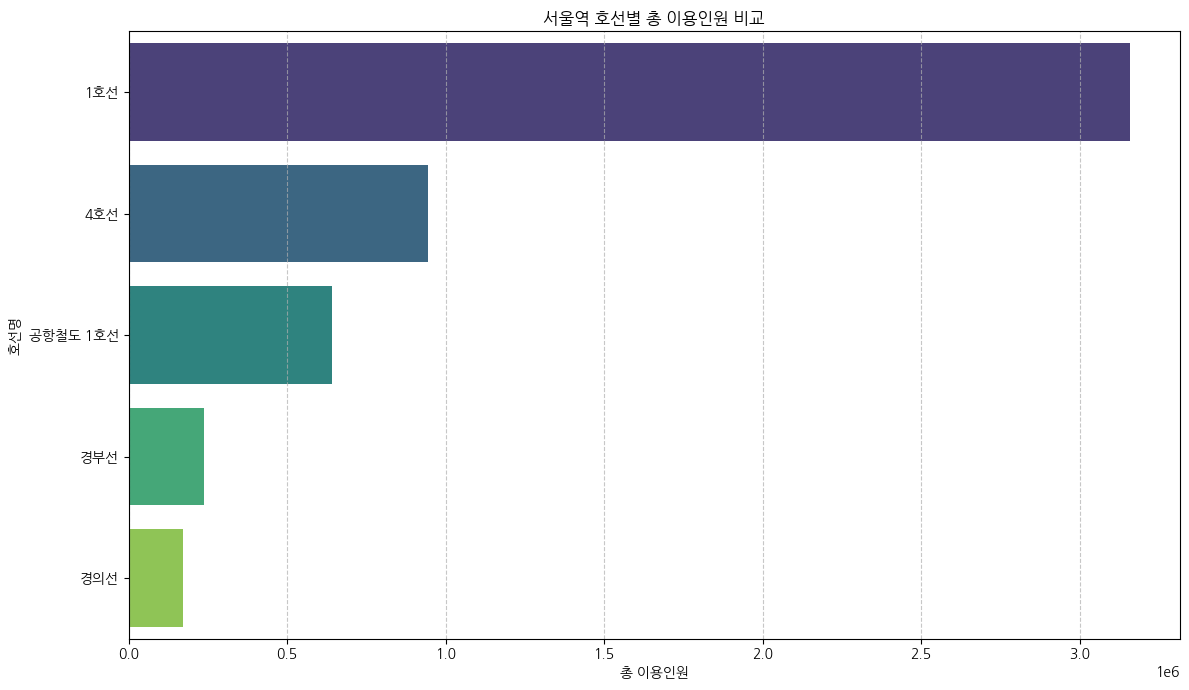

In [ ]:
seoul_station_df = df[df['지하철역'] == '서울역'].copy()
seoul_station_df['총이용이원'] = df['총승차인원'] + df['총하차인원']

# 서울역에 들어오는 호선별 총 승차인원 집계
line_boarding_at_seoul_station = seoul_station_df.groupby('호선명')['총이용이원'].mean().reset_index()

# 총 승차인원 기준으로 내림차순 정렬
line_boarding_at_seoul_station = line_boarding_at_seoul_station.sort_values(by='총이용이원', ascending=False)

# 그래프 그리기
plt.figure(figsize=(12, 7))
sns.barplot(x='총이용이원', y='호선명', data=line_boarding_at_seoul_station, palette='viridis', hue='호선명', legend=False)

plt.title('서울역 호선별 총 이용인원 비교')
plt.xlabel('총 이용인원')
plt.ylabel('호선명')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

서울역은 1호선을 이용하는 인원이 압도적으로 많고, 그 다음이 4호선과 공항철도 1호선이고 경부선과 경의선은 거의 이용하지 않습니다.

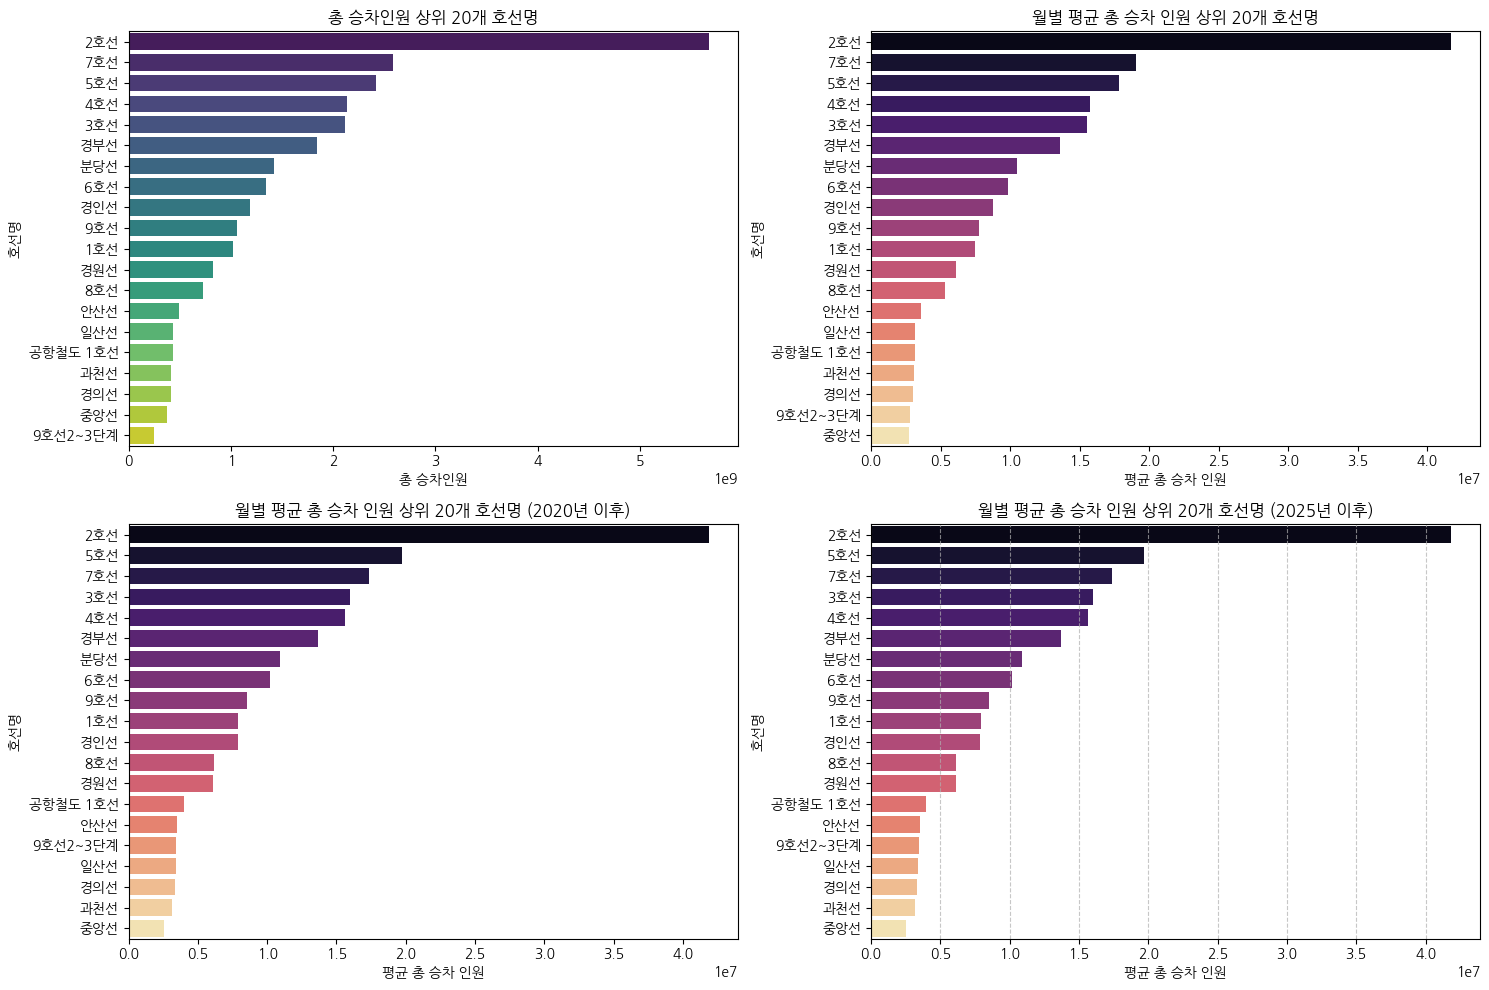

In [ ]:
# 지하철역별 총승차인원 집계
station_boarding = df.groupby('호선명')['총승차인원'].sum().reset_index()

# 총승차인원 기준으로 내림차순 정렬 후 상위 20개 역 선택
top_10_stations = station_boarding.sort_values(by='총승차인원', ascending=False).head(20)

# 막대 그래프 그리기
plt.figure(figsize=(15, 10))

plt.subplot(221)
sns.barplot(x='총승차인원', y='호선명', data=top_10_stations, palette='viridis', hue='호선명', legend=False)

plt.title('총 승차인원 상위 20개 호선명')
plt.xlabel('총 승차인원')
plt.ylabel('호선명')


# 1. 먼저 같은 달, 같은 역의 여러 노선 데이터를 합칩니다.
monthly_station_sum = df.groupby(['사용월', '호선명'])['총승차인원'].sum().reset_index()

# 2. 합쳐진 데이터를 바탕으로 역별 월평균을 구합니다.
correct_average = monthly_station_sum.groupby('호선명')['총승차인원'].mean().reset_index()

# 평균 총 이용 인원 기준으로 내림차순 정렬 후 상위 20개 역 선택
top_10_average_stations = correct_average.sort_values(by='총승차인원', ascending=False).head(20)

# 막대 그래프 그리기
plt.subplot(222)
sns.barplot(x='총승차인원', y='호선명', data=top_10_average_stations, palette='magma', hue='호선명', legend=False)

plt.title('월별 평균 총 승차 인원 상위 20개 호선명')
plt.xlabel('평균 총 승차 인원')
plt.ylabel('호선명')

df_2020 = df[df["사용월"].dt.year >= 2020]

# 1. 먼저 같은 달, 같은 역의 여러 노선 데이터를 합칩니다.
monthly_station_sum = df_2025.groupby(['사용월', '호선명'])['총승차인원'].sum().reset_index()

# 2. 합쳐진 데이터를 바탕으로 역별 월평균을 구합니다.
correct_average = monthly_station_sum.groupby('호선명')['총승차인원'].mean().reset_index()

# 평균 총 이용 인원 기준으로 내림차순 정렬 후 상위 20개 역 선택
top_10_average_stations = correct_average.sort_values(by='총승차인원', ascending=False).head(20)

# 막대 그래프 그리기
plt.subplot(223)
sns.barplot(x='총승차인원', y='호선명', data=top_10_average_stations, palette='magma', hue='호선명', legend=False)

plt.title('월별 평균 총 승차 인원 상위 20개 호선명 (2020년 이후)')
plt.xlabel('평균 총 승차 인원')
plt.ylabel('호선명')

df_2025 = df[df["사용월"].dt.year >= 2025]

# 1. 먼저 같은 달, 같은 역의 여러 노선 데이터를 합칩니다.
monthly_station_sum = df_2025.groupby(['사용월', '호선명'])['총승차인원'].sum().reset_index()

# 2. 합쳐진 데이터를 바탕으로 역별 월평균을 구합니다.
correct_average = monthly_station_sum.groupby('호선명')['총승차인원'].mean().reset_index()

# 평균 총 이용 인원 기준으로 내림차순 정렬 후 상위 20개 역 선택
top_10_average_stations = correct_average.sort_values(by='총승차인원', ascending=False).head(20)

# 막대 그래프 그리기
plt.subplot(224)
sns.barplot(x='총승차인원', y='호선명', data=top_10_average_stations, palette='magma', hue='호선명', legend=False)

plt.title('월별 평균 총 승차 인원 상위 20개 호선명 (2025년 이후)')
plt.xlabel('평균 총 승차 인원')
plt.ylabel('호선명')


plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

2호선이 압도적인 이용률을 보여줍니다. 2위인 5호선과 7호선에 비해 2배 가까운 차이가 존재합니다.

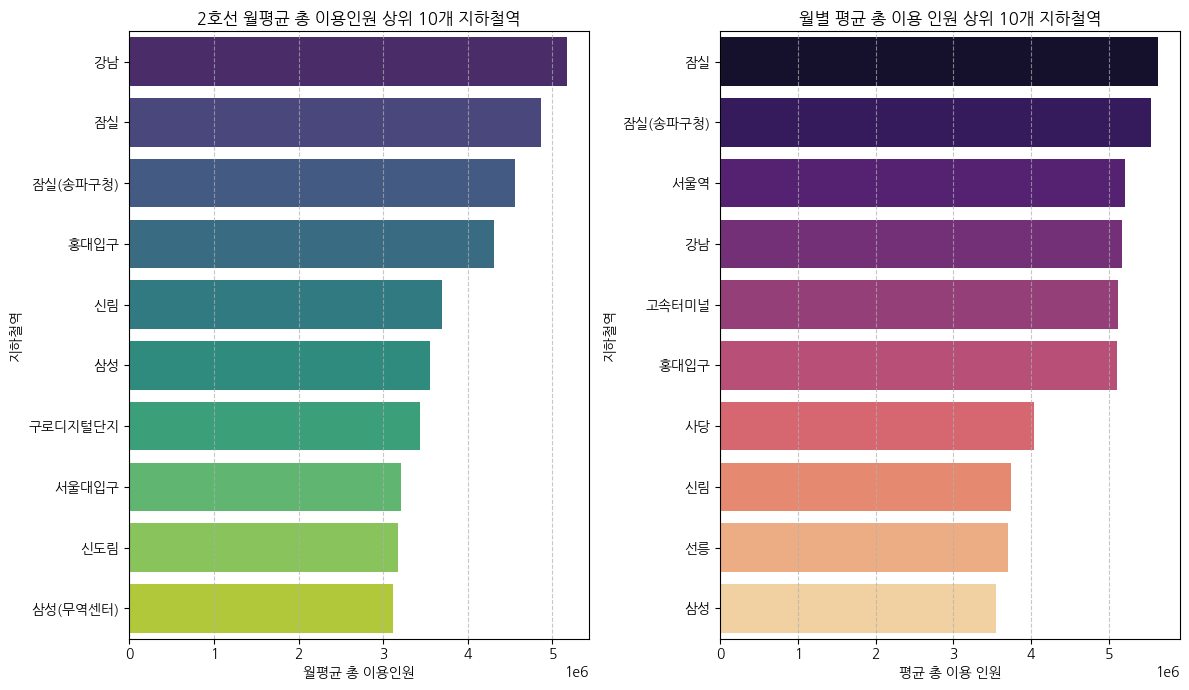

In [ ]:
line2_df = df[df['호선명'] == '2호선'].copy()

line2_df['총이용인원'] = df['총승차인원'] + df['총하차인원']

# '사용월', '지하철역' 별로 총 이용인원 합산
monthly_station_usage_line2 = line2_df.groupby(['사용월', '지하철역'])['총이용인원'].sum().reset_index()

# 각 역의 월평균 총 이용인원 계산
average_monthly_usage_line2 = monthly_station_usage_line2.groupby('지하철역')['총이용인원'].mean().reset_index()

# 월평균 총 이용인원 기준으로 내림차순 정렬 후 상위 10개 역 선택
top_10_line2_stations = average_monthly_usage_line2.sort_values(by='총이용인원', ascending=False).head(10)

# 그래프 그리기
plt.figure(figsize=(12, 7))
plt.subplot(121)
sns.barplot(x='총이용인원', y='지하철역', data=top_10_line2_stations, palette='viridis', hue='지하철역', legend=False)

plt.title('2호선 월평균 총 이용인원 상위 10개 지하철역')
plt.xlabel('월평균 총 이용인원')
plt.ylabel('지하철역')
plt.grid(axis='x', linestyle='--', alpha=0.7)

new_df = df.copy()
new_df['총이용인원'] = df['총승차인원'] + df['총하차인원']

# 1. 먼저 같은 달, 같은 역의 여러 노선 데이터를 합칩니다.
monthly_station_sum = new_df.groupby(['사용월', '지하철역'])['총이용인원'].sum().reset_index()

# 2. 합쳐진 데이터를 바탕으로 역별 월평균을 구합니다.
correct_average = monthly_station_sum.groupby('지하철역')['총이용인원'].mean().reset_index()

# 평균 총 이용 인원 기준으로 내림차순 정렬 후 상위 20개 역 선택
top_10_average_stations = correct_average.sort_values(by='총이용인원', ascending=False).head(10)

# 막대 그래프 그리기
plt.subplot(122)
sns.barplot(x='총이용인원', y='지하철역', data=top_10_average_stations, palette='magma', hue='지하철역', legend=False)

plt.title('월별 평균 총 이용 인원 상위 10개 지하철역')
plt.xlabel('평균 총 이용 인원')
plt.ylabel('지하철역')

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

2호선의 압도적인 이용률 때문인지 상위 10개 역과 전체 평균 10개 역이 비슷합니다.

잠실은 잠실(송파구청)역으로 바뀌었으니 잠실은 제외하고 봐도 잠실(송파구청), 강남, 홍대입구, 신림 등 상위권 역이 대거 포함되어 있습니다.

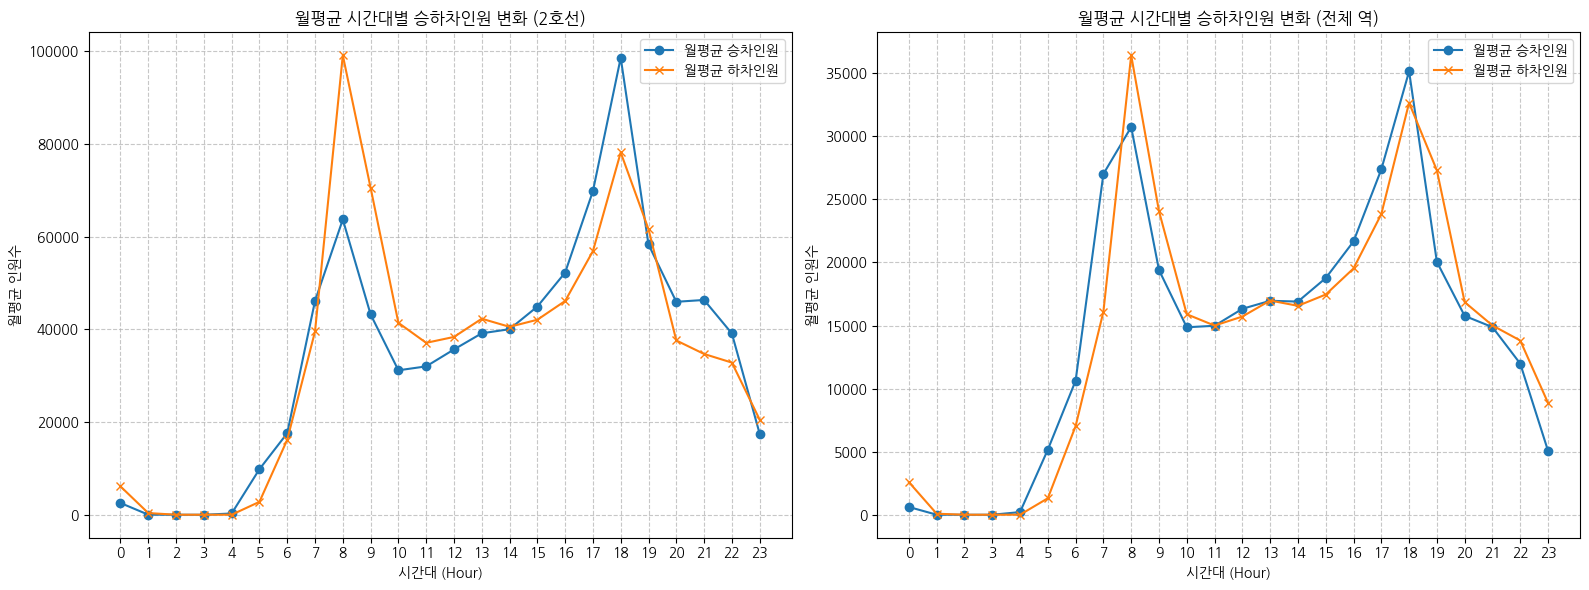

In [8]:
jamsil_df = df[df['호선명'] == '2호선']

# 시간대별 승차 및 하차 인원 평균을 저장할 딕셔너리 초기화
hourly_ride_averages_jamsil = {}
hourly_alight_averages_jamsil = {}

# 00시부터 23시까지 각 시간대별 승차/하차 인원 평균 계산
for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in jamsil_df.columns:
        hourly_ride_averages_jamsil[i] = jamsil_df[ride_col].mean()
    else:
        hourly_ride_averages_jamsil[i] = 0

    if alight_col in jamsil_df.columns:
        hourly_alight_averages_jamsil[i] = jamsil_df[alight_col].mean()
    else:
        hourly_alight_averages_jamsil[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_jamsil = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_jamsil[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_jamsil[hour] for hour in range(24)]
})

# 그래프 그리기
plt.figure(figsize=(16, 6))

plt.subplot(121)
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (2호선)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


# 전체 역에 대한 월평균 시간대별 승차 및 하차 인원 계산
hourly_ride_averages_all = {}
hourly_alight_averages_all = {}

for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in df.columns:
        hourly_ride_averages_all[i] = df[ride_col].mean()
    else:
        hourly_ride_averages_all[i] = 0

    if alight_col in df.columns:
        hourly_alight_averages_all[i] = df[alight_col].mean()
    else:
        hourly_alight_averages_all[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_all = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_all[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_all[hour] for hour in range(24)]
})

# 그래프 그리기
plt.subplot(122)
plt.plot(hourly_activity_df_all['시간'], hourly_activity_df_all['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_all['시간'], hourly_activity_df_all['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (전체 역)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

2호선의 승하차 인원은 평범한 지표를 보여줍니다.

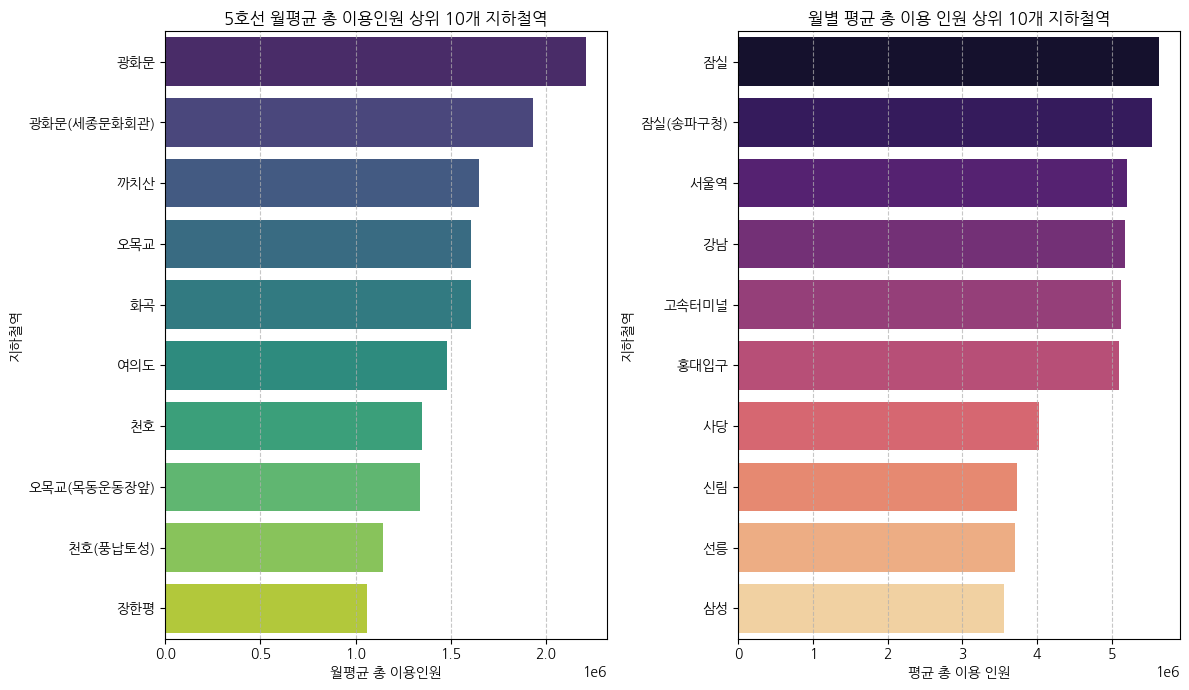

In [10]:
line2_df = df[df['호선명'] == '5호선'].copy()

line2_df['총이용인원'] = df['총승차인원'] + df['총하차인원']

# '사용월', '지하철역' 별로 총 이용인원 합산
monthly_station_usage_line2 = line2_df.groupby(['사용월', '지하철역'])['총이용인원'].sum().reset_index()

# 각 역의 월평균 총 이용인원 계산
average_monthly_usage_line2 = monthly_station_usage_line2.groupby('지하철역')['총이용인원'].mean().reset_index()

# 월평균 총 이용인원 기준으로 내림차순 정렬 후 상위 10개 역 선택
top_10_line2_stations = average_monthly_usage_line2.sort_values(by='총이용인원', ascending=False).head(10)

# 그래프 그리기
plt.figure(figsize=(12, 7))
plt.subplot(121)
sns.barplot(x='총이용인원', y='지하철역', data=top_10_line2_stations, palette='viridis', hue='지하철역', legend=False)

plt.title('5호선 월평균 총 이용인원 상위 10개 지하철역')
plt.xlabel('월평균 총 이용인원')
plt.ylabel('지하철역')
plt.grid(axis='x', linestyle='--', alpha=0.7)

new_df = df.copy()
new_df['총이용인원'] = df['총승차인원'] + df['총하차인원']

# 1. 먼저 같은 달, 같은 역의 여러 노선 데이터를 합칩니다.
monthly_station_sum = new_df.groupby(['사용월', '지하철역'])['총이용인원'].sum().reset_index()

# 2. 합쳐진 데이터를 바탕으로 역별 월평균을 구합니다.
correct_average = monthly_station_sum.groupby('지하철역')['총이용인원'].mean().reset_index()

# 평균 총 이용 인원 기준으로 내림차순 정렬 후 상위 20개 역 선택
top_10_average_stations = correct_average.sort_values(by='총이용인원', ascending=False).head(10)

# 막대 그래프 그리기
plt.subplot(122)
sns.barplot(x='총이용인원', y='지하철역', data=top_10_average_stations, palette='magma', hue='지하철역', legend=False)

plt.title('월별 평균 총 이용 인원 상위 10개 지하철역')
plt.xlabel('평균 총 이용 인원')
plt.ylabel('지하철역')

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

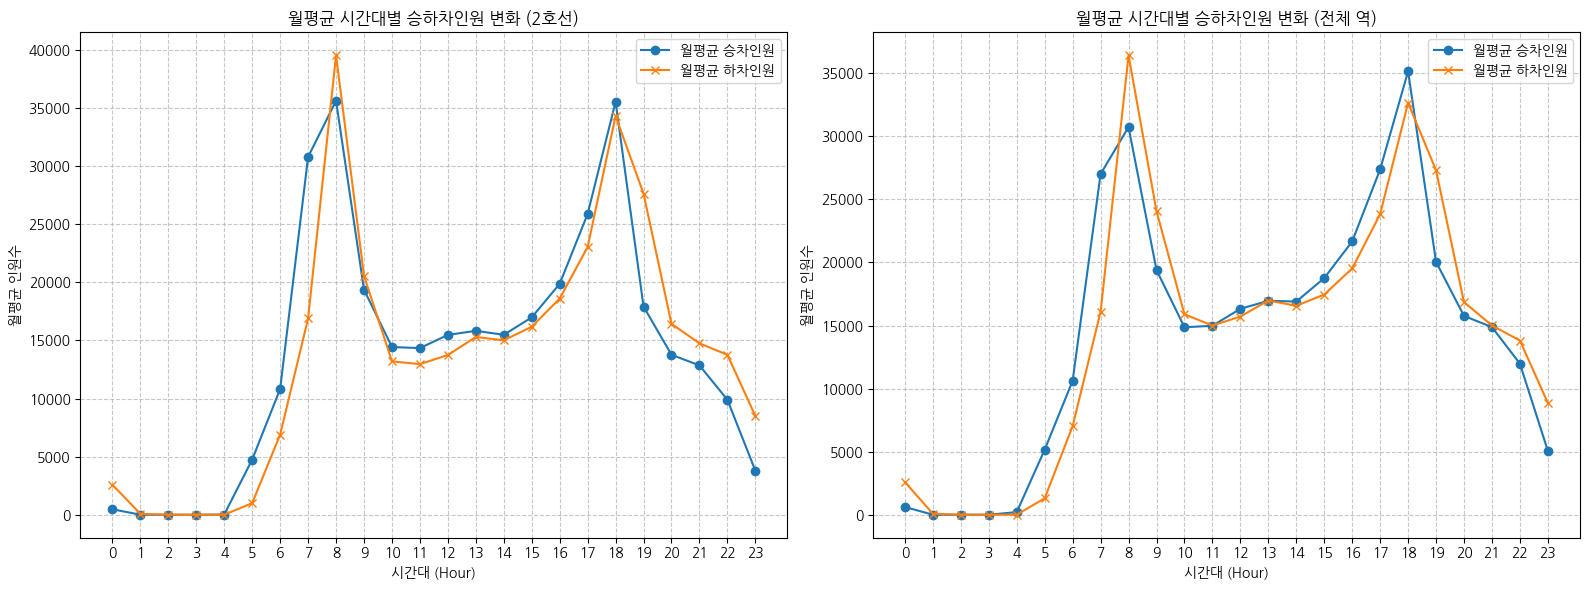

In [11]:
jamsil_df = df[df['호선명'] == '5호선']

# 시간대별 승차 및 하차 인원 평균을 저장할 딕셔너리 초기화
hourly_ride_averages_jamsil = {}
hourly_alight_averages_jamsil = {}

# 00시부터 23시까지 각 시간대별 승차/하차 인원 평균 계산
for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in jamsil_df.columns:
        hourly_ride_averages_jamsil[i] = jamsil_df[ride_col].mean()
    else:
        hourly_ride_averages_jamsil[i] = 0

    if alight_col in jamsil_df.columns:
        hourly_alight_averages_jamsil[i] = jamsil_df[alight_col].mean()
    else:
        hourly_alight_averages_jamsil[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_jamsil = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_jamsil[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_jamsil[hour] for hour in range(24)]
})

# 그래프 그리기
plt.figure(figsize=(16, 6))

plt.subplot(121)
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (2호선)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


# 전체 역에 대한 월평균 시간대별 승차 및 하차 인원 계산
hourly_ride_averages_all = {}
hourly_alight_averages_all = {}

for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in df.columns:
        hourly_ride_averages_all[i] = df[ride_col].mean()
    else:
        hourly_ride_averages_all[i] = 0

    if alight_col in df.columns:
        hourly_alight_averages_all[i] = df[alight_col].mean()
    else:
        hourly_alight_averages_all[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_all = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_all[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_all[hour] for hour in range(24)]
})

# 그래프 그리기
plt.subplot(122)
plt.plot(hourly_activity_df_all['시간'], hourly_activity_df_all['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_all['시간'], hourly_activity_df_all['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (전체 역)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

5호선의 상위 10개 역과 전체 상위 10개 역은 겹치는 것이 없고, 시간대 지표 또한 매우 평범한 지표를 보여줍니다.

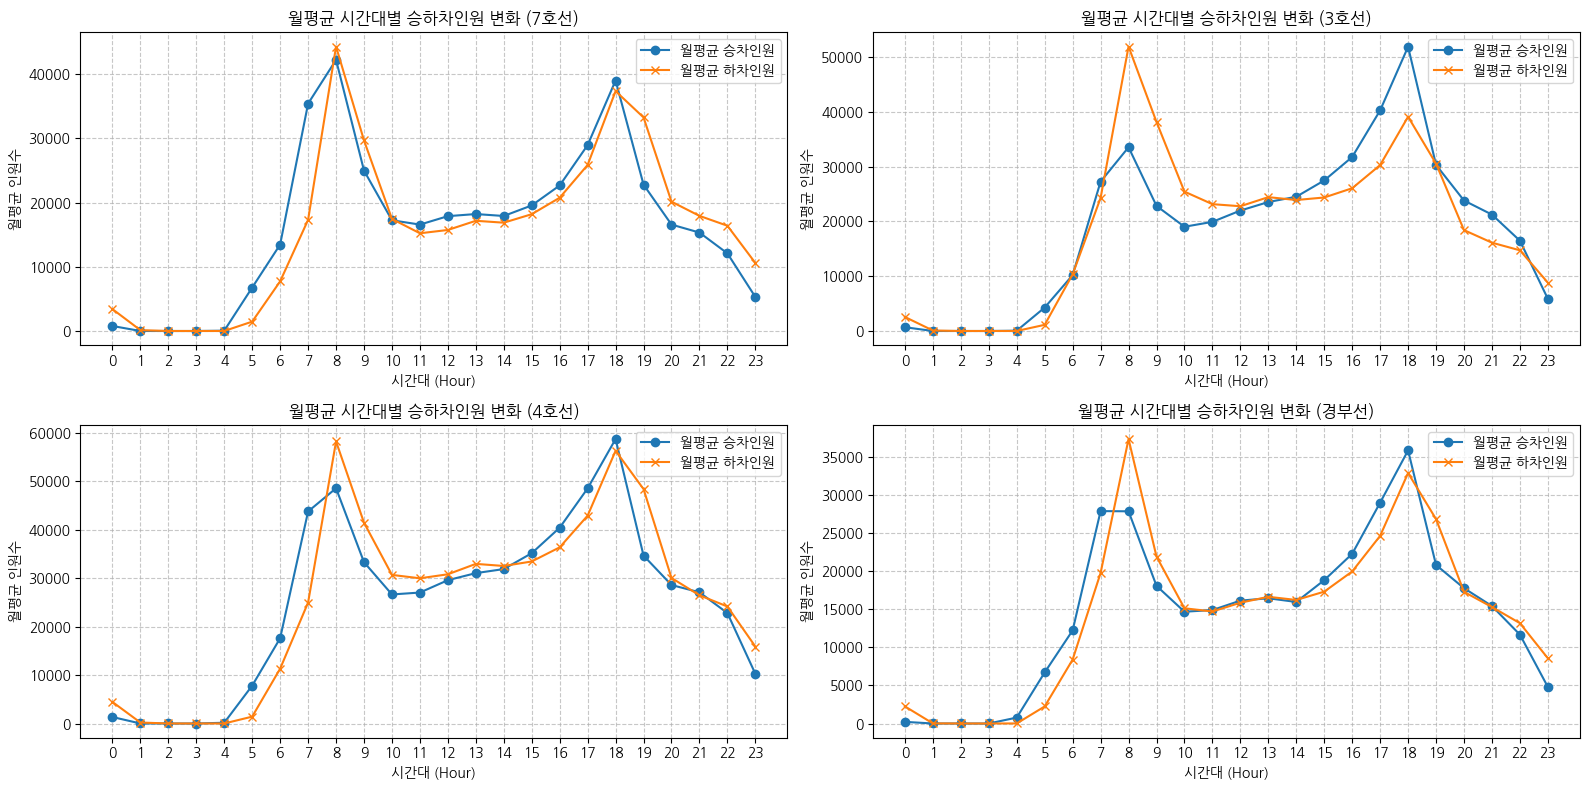

In [12]:
jamsil_df = df[df['호선명'] == '7호선']

# 시간대별 승차 및 하차 인원 평균을 저장할 딕셔너리 초기화
hourly_ride_averages_jamsil = {}
hourly_alight_averages_jamsil = {}

# 00시부터 23시까지 각 시간대별 승차/하차 인원 평균 계산
for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in jamsil_df.columns:
        hourly_ride_averages_jamsil[i] = jamsil_df[ride_col].mean()
    else:
        hourly_ride_averages_jamsil[i] = 0

    if alight_col in jamsil_df.columns:
        hourly_alight_averages_jamsil[i] = jamsil_df[alight_col].mean()
    else:
        hourly_alight_averages_jamsil[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_jamsil = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_jamsil[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_jamsil[hour] for hour in range(24)]
})

# 그래프 그리기
plt.figure(figsize=(16, 8))

plt.subplot(221)
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (7호선)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

jamsil_df = df[df['호선명'] == '3호선']

# 시간대별 승차 및 하차 인원 평균을 저장할 딕셔너리 초기화
hourly_ride_averages_jamsil = {}
hourly_alight_averages_jamsil = {}

# 00시부터 23시까지 각 시간대별 승차/하차 인원 평균 계산
for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in jamsil_df.columns:
        hourly_ride_averages_jamsil[i] = jamsil_df[ride_col].mean()
    else:
        hourly_ride_averages_jamsil[i] = 0

    if alight_col in jamsil_df.columns:
        hourly_alight_averages_jamsil[i] = jamsil_df[alight_col].mean()
    else:
        hourly_alight_averages_jamsil[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_jamsil = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_jamsil[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_jamsil[hour] for hour in range(24)]
})

# 그래프 그리기
plt.subplot(222)
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (3호선)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


jamsil_df = df[df['호선명'] == '4호선']

# 시간대별 승차 및 하차 인원 평균을 저장할 딕셔너리 초기화
hourly_ride_averages_jamsil = {}
hourly_alight_averages_jamsil = {}

# 00시부터 23시까지 각 시간대별 승차/하차 인원 평균 계산
for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in jamsil_df.columns:
        hourly_ride_averages_jamsil[i] = jamsil_df[ride_col].mean()
    else:
        hourly_ride_averages_jamsil[i] = 0

    if alight_col in jamsil_df.columns:
        hourly_alight_averages_jamsil[i] = jamsil_df[alight_col].mean()
    else:
        hourly_alight_averages_jamsil[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_jamsil = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_jamsil[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_jamsil[hour] for hour in range(24)]
})

# 그래프 그리기
plt.subplot(223)
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (4호선)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


jamsil_df = df[df['호선명'] == '경부선']

# 전체 역에 대한 월평균 시간대별 승차 및 하차 인원 계산
hourly_ride_averages_all = {}
hourly_alight_averages_all = {}

for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in jamsil_df.columns:
        hourly_ride_averages_all[i] = jamsil_df[ride_col].mean()
    else:
        hourly_ride_averages_all[i] = 0

    if alight_col in jamsil_df.columns:
        hourly_alight_averages_all[i] = jamsil_df[alight_col].mean()
    else:
        hourly_alight_averages_all[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_all = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_all[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_all[hour] for hour in range(24)]
})

# 그래프 그리기
plt.subplot(224)
plt.plot(hourly_activity_df_all['시간'], hourly_activity_df_all['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_all['시간'], hourly_activity_df_all['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (경부선)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

호선별로 놓고 봤을 때에는 비교적 평범한 지표를 보여줍니다.

단일 역만 놓고 보면 역 주변의 상황에 따라 독특한 지표를 보여주는 반면, 호선의 경우 여러 역의 평균으로 구해지다 보니 평범한 지표를 가지게 된 것 같습니다.

서울역을 지나가는 호선이 많았는데 서울역의 지표가 평범했었기 때문에, 혹시 역을 지나가는 호선이 많으면 지표가 평범해지는지 확인합니다.

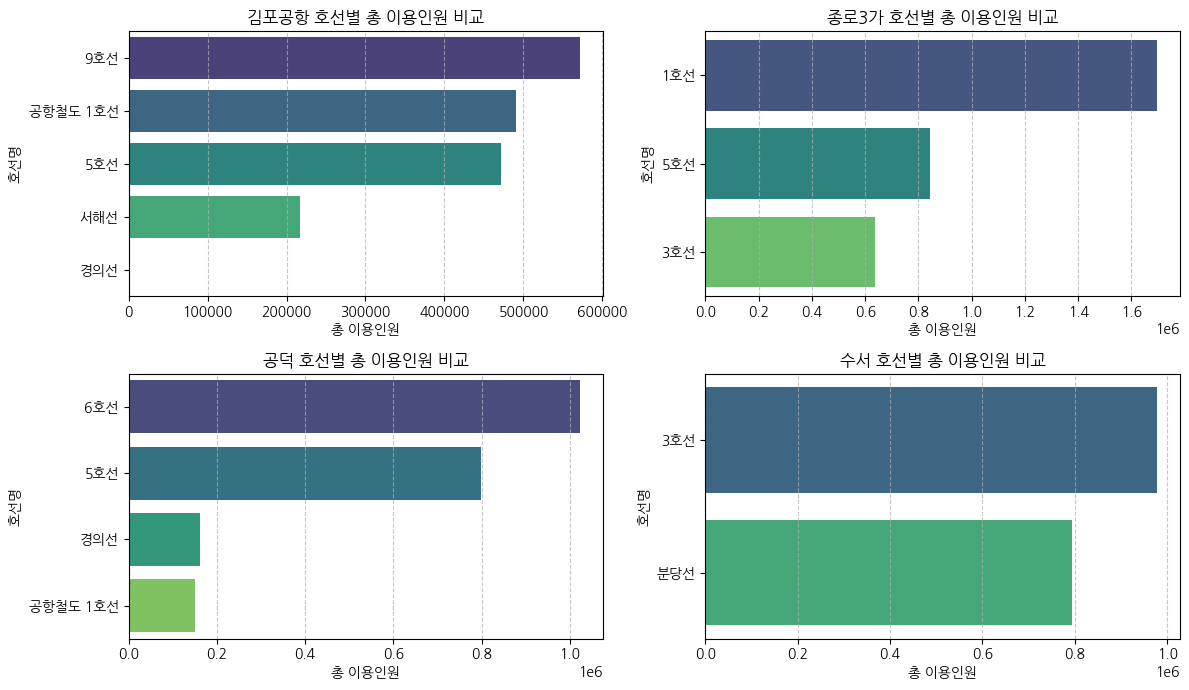

In [22]:
seoul_station_df = df[df['지하철역'] == '김포공항'].copy()
seoul_station_df['총이용이원'] = df['총승차인원'] + df['총하차인원']

# 서울역에 들어오는 호선별 총 승차인원 집계
line_boarding_at_seoul_station = seoul_station_df.groupby('호선명')['총이용이원'].mean().reset_index()

# 총 승차인원 기준으로 내림차순 정렬
line_boarding_at_seoul_station = line_boarding_at_seoul_station.sort_values(by='총이용이원', ascending=False)

# 그래프 그리기
plt.figure(figsize=(12, 7))

plt.subplot(221)
sns.barplot(x='총이용이원', y='호선명', data=line_boarding_at_seoul_station, palette='viridis', hue='호선명', legend=False)

plt.title('김포공항 호선별 총 이용인원 비교')
plt.xlabel('총 이용인원')
plt.ylabel('호선명')
plt.grid(axis='x', linestyle='--', alpha=0.7)


seoul_station_df = df[df['지하철역'] == '종로3가'].copy()
seoul_station_df['총이용이원'] = df['총승차인원'] + df['총하차인원']

# 서울역에 들어오는 호선별 총 승차인원 집계
line_boarding_at_seoul_station = seoul_station_df.groupby('호선명')['총이용이원'].mean().reset_index()

# 총 승차인원 기준으로 내림차순 정렬
line_boarding_at_seoul_station = line_boarding_at_seoul_station.sort_values(by='총이용이원', ascending=False)

# 그래프 그리기
plt.subplot(222)
sns.barplot(x='총이용이원', y='호선명', data=line_boarding_at_seoul_station, palette='viridis', hue='호선명', legend=False)

plt.title('종로3가 호선별 총 이용인원 비교')
plt.xlabel('총 이용인원')
plt.ylabel('호선명')
plt.grid(axis='x', linestyle='--', alpha=0.7)

seoul_station_df = df[df['지하철역'] == '공덕'].copy()
seoul_station_df['총이용이원'] = df['총승차인원'] + df['총하차인원']

# 서울역에 들어오는 호선별 총 승차인원 집계
line_boarding_at_seoul_station = seoul_station_df.groupby('호선명')['총이용이원'].mean().reset_index()

# 총 승차인원 기준으로 내림차순 정렬
line_boarding_at_seoul_station = line_boarding_at_seoul_station.sort_values(by='총이용이원', ascending=False)

# 그래프 그리기
plt.subplot(223)
sns.barplot(x='총이용이원', y='호선명', data=line_boarding_at_seoul_station, palette='viridis', hue='호선명', legend=False)

plt.title('공덕 호선별 총 이용인원 비교')
plt.xlabel('총 이용인원')
plt.ylabel('호선명')
plt.grid(axis='x', linestyle='--', alpha=0.7)

seoul_station_df = df[df['지하철역'] == '수서'].copy()
seoul_station_df['총이용이원'] = df['총승차인원'] + df['총하차인원']

# 서울역에 들어오는 호선별 총 승차인원 집계
line_boarding_at_seoul_station = seoul_station_df.groupby('호선명')['총이용이원'].mean().reset_index()

# 총 승차인원 기준으로 내림차순 정렬
line_boarding_at_seoul_station = line_boarding_at_seoul_station.sort_values(by='총이용이원', ascending=False)

# 그래프 그리기
plt.subplot(224)
sns.barplot(x='총이용이원', y='호선명', data=line_boarding_at_seoul_station, palette='viridis', hue='호선명', legend=False)

plt.title('수서 호선별 총 이용인원 비교')
plt.xlabel('총 이용인원')
plt.ylabel('호선명')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# ---

plt.tight_layout()
plt.show()

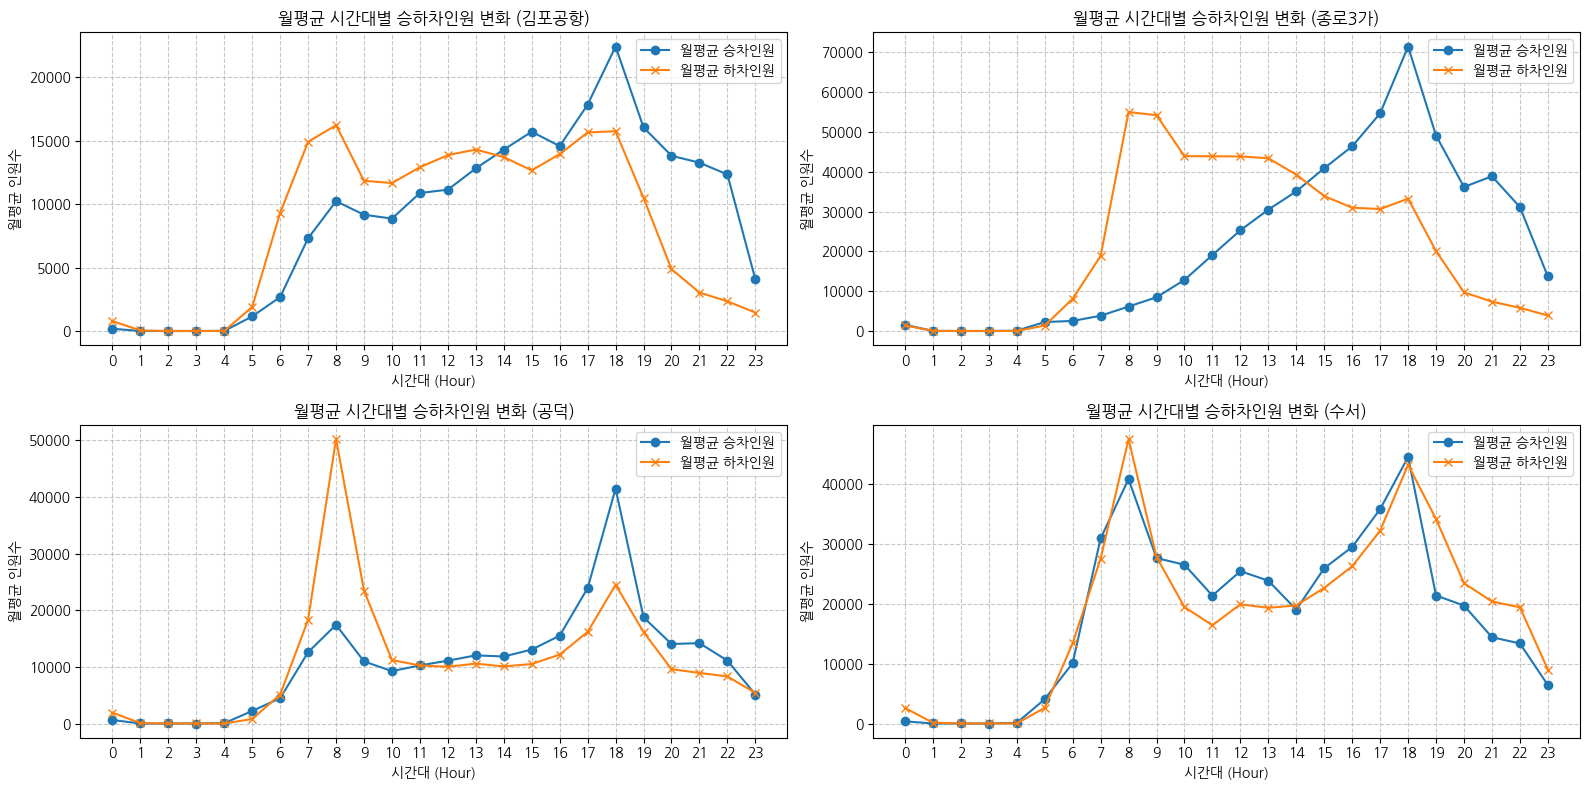

In [23]:
jamsil_df = df[df['지하철역'] == '김포공항']

# 시간대별 승차 및 하차 인원 평균을 저장할 딕셔너리 초기화
hourly_ride_averages_jamsil = {}
hourly_alight_averages_jamsil = {}

# 00시부터 23시까지 각 시간대별 승차/하차 인원 평균 계산
for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in jamsil_df.columns:
        hourly_ride_averages_jamsil[i] = jamsil_df[ride_col].mean()
    else:
        hourly_ride_averages_jamsil[i] = 0

    if alight_col in jamsil_df.columns:
        hourly_alight_averages_jamsil[i] = jamsil_df[alight_col].mean()
    else:
        hourly_alight_averages_jamsil[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_jamsil = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_jamsil[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_jamsil[hour] for hour in range(24)]
})

# 그래프 그리기
plt.figure(figsize=(16, 8))

plt.subplot(221)
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (김포공항)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

jamsil_df = df[df['지하철역'] == '종로3가']

# 시간대별 승차 및 하차 인원 평균을 저장할 딕셔너리 초기화
hourly_ride_averages_jamsil = {}
hourly_alight_averages_jamsil = {}

# 00시부터 23시까지 각 시간대별 승차/하차 인원 평균 계산
for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in jamsil_df.columns:
        hourly_ride_averages_jamsil[i] = jamsil_df[ride_col].mean()
    else:
        hourly_ride_averages_jamsil[i] = 0

    if alight_col in jamsil_df.columns:
        hourly_alight_averages_jamsil[i] = jamsil_df[alight_col].mean()
    else:
        hourly_alight_averages_jamsil[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_jamsil = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_jamsil[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_jamsil[hour] for hour in range(24)]
})

# 그래프 그리기
plt.subplot(222)
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (종로3가)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


jamsil_df = df[df['지하철역'] == '공덕']

# 시간대별 승차 및 하차 인원 평균을 저장할 딕셔너리 초기화
hourly_ride_averages_jamsil = {}
hourly_alight_averages_jamsil = {}

# 00시부터 23시까지 각 시간대별 승차/하차 인원 평균 계산
for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in jamsil_df.columns:
        hourly_ride_averages_jamsil[i] = jamsil_df[ride_col].mean()
    else:
        hourly_ride_averages_jamsil[i] = 0

    if alight_col in jamsil_df.columns:
        hourly_alight_averages_jamsil[i] = jamsil_df[alight_col].mean()
    else:
        hourly_alight_averages_jamsil[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_jamsil = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_jamsil[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_jamsil[hour] for hour in range(24)]
})

# 그래프 그리기
plt.subplot(223)
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_jamsil['시간'], hourly_activity_df_jamsil['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (공덕)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


jamsil_df = df[df['지하철역'] == '수서']

# 전체 역에 대한 월평균 시간대별 승차 및 하차 인원 계산
hourly_ride_averages_all = {}
hourly_alight_averages_all = {}

for i in range(24):
    ride_col = f'{i:02d}시-{i+1:02d}시 승차인원'
    alight_col = f'{i:02d}시-{i+1:02d}시 하차인원'

    if ride_col in jamsil_df.columns:
        hourly_ride_averages_all[i] = jamsil_df[ride_col].mean()
    else:
        hourly_ride_averages_all[i] = 0

    if alight_col in jamsil_df.columns:
        hourly_alight_averages_all[i] = jamsil_df[alight_col].mean()
    else:
        hourly_alight_averages_all[i] = 0

# 결과를 DataFrame으로 변환
hourly_activity_df_all = pd.DataFrame({
    '시간': list(range(24)),
    '월평균 승차인원': [hourly_ride_averages_all[hour] for hour in range(24)],
    '월평균 하차인원': [hourly_alight_averages_all[hour] for hour in range(24)]
})

# 그래프 그리기
plt.subplot(224)
plt.plot(hourly_activity_df_all['시간'], hourly_activity_df_all['월평균 승차인원'], label='월평균 승차인원', marker='o')
plt.plot(hourly_activity_df_all['시간'], hourly_activity_df_all['월평균 하차인원'], label='월평균 하차인원', marker='x')

plt.title('월평균 시간대별 승하차인원 변화 (수서)')
plt.xlabel('시간대 (Hour)')
plt.ylabel('월평균 인원수')
plt.xticks(range(24)) # 0부터 23까지 모든 시간대 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

지나가는 호선이 2개 이상인 역을 무작위로 선정해 보았습니다.

공덕과 수서는 평범했지만 김포공항과 종로3가는 그렇지 않았습니다.

지나가는 호선이 많다고 해서 그 특징성이 사라지기 보다는 역마다 살아있는 것을 확인할 수 있었습니다.

호선의 경우 지나가는 역이 워낙 많다보니 특징성이 사라지고 평균으로 수렴하지만, 개별 역의 경우 많아도 호선이 5개 정도에 불과하다 보니 김포공항과 같이 뚜렷한 특징이 있는 곳은 그 특징이 사라지지 않는 것을 확인할 수 있었습니다.